# ASAP7 passive DoC shared dendritic voltage attribution — all sessions/mice

This notebook asks how much of the shared dendritic voltage signal is explained by passive-task variables:

- repeated image presentations
- image identity
- image changes
- image omissions
- running speed/velocity/acceleration
- slow non-event-locked drift

The analysis is designed for the full-session trace H5 files so that voltage, stimulus events, and running are all represented in **session-relative HARP seconds**. HARP is treated as the master clock. Imaging is expected to start a few seconds after Bonsai/HARP acquisition begins, so voltage timebases that begin near zero are shifted onto the detected imaging epoch.

The notebook is Python 3.9 compatible and avoids hit, miss, lick, reward, engagement, and strategy regressors because this dataset uses passive detection-of-change sessions.

In [1]:
from pathlib import Path
from types import SimpleNamespace
from datetime import datetime
import os
import sys
import glob
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.ndimage import gaussian_filter1d
from scipy.signal import medfilt

try:
    import h5py
except Exception as exc:
    raise ImportError("h5py is required to read full-session voltage trace H5 files")

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
if HAS_SEABORN:
    sns.set_context("talk", font_scale=0.75)
    sns.set_style("whitegrid")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

In [4]:
today_str = datetime.today().strftime("%Y-%m-%d")

BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")
SUMMARY_XLSX = BASE_PATH / "VIP_SD_summary.xlsx"

# Add your local repo checkout here if needed. Leave as None if the package is installed/editable.
LOCAL_REPO_SRC = None  # e.g. Path(r"C:\\Users\\andrew.shelton\\code\\vip-slap2-analysis\\src")
if LOCAL_REPO_SRC is not None and str(LOCAL_REPO_SRC) not in sys.path:
    sys.path.insert(0, str(LOCAL_REPO_SRC))

TARGET_MICE = [826031, 826032]
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
REQUIRE_QUALITY = "good"
REQUIRE_BEHAVIOR_PROCESSED = True

# Data source. Canonical traces should be the full-session derived H5.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL_NAME = "dff"
ALLOW_FALLBACK_TO_EXTRACTION_TRACE_H5 = False
VALID_ROIS_ONLY = True
USE_RECOMMENDED_ROIS = True

# Running wheel constants.
TICKS_PER_REVOLUTION = 8192.0
WHEEL_RADIUS_CM = 8.25

# Regression settings.
REG_TARGET_FS_HZ = 100.0       # 10 ms sample grid; preserves voltage-timing advantages over calcium.
EVENT_BIN_WIDTH_SEC = 0.05     # stable FIR bins; decrease to 0.025 if you need finer kernels.
N_DRIFT_BASIS = 12
RIDGE_ALPHA = 10.0
N_CV_FOLDS = 5

# Event kernel windows. They may overlap across the 0.75 s image cadence; ridge handles the collinearity.
EVENT_WINDOWS = {
    "image_flash": (-0.75, 1.25),
    "image_identity": (-0.75, 1.25),
    "change": (-0.75, 1.75),
    "omission": (-0.75, 1.75),
}
RUNNING_LAGS_SEC = (-1.0, -0.5, 0.0, 0.5, 1.0)

# Frequency-domain QC. Main image cadence is 1 / 0.75 s.
IMAGE_CADENCE_HZ = 1.0 / 0.75
CADENCE_HARMONICS = 5
CADENCE_BAND_HALF_WIDTH_HZ = 0.05

# Smoke-test controls. Leave as None for full sessions / all sessions.
MAX_SECONDS_PER_SESSION = None
MAX_SESSIONS = None
RUN_ALL_SESSIONS = True

# Output directory for lab-meeting tables/figures. Change to your presentation folder if desired.
SAVE_ROOT = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV")
FIG_DIR = SAVE_ROOT / "figures"
TABLE_DIR = SAVE_ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("SAVE_ROOT:", SAVE_ROOT)

SAVE_ROOT: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV


## Lightweight Python 3.9-compatible registry and path utilities

In [5]:
def _norm_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def _norm_key(x):
    return _norm_text(x).lower().replace(" ", "_")


def _coerce_path(x):
    if x is None or pd.isna(x):
        return None
    return Path(str(x))


def _find_matches(base, pattern):
    if base is None:
        return []
    base = Path(base)
    try:
        if not base.exists():
            return []
    except OSError:
        return []
    return [Path(p) for p in sorted(glob.glob(str(base / "**" / pattern), recursive=True))]


def _path_contains_parts(path, parts):
    lower_parts = [p.lower() for p in Path(path).parts]
    start = 0
    for part in parts:
        target = str(part).lower()
        try:
            idx = lower_parts.index(target, start)
        except ValueError:
            return False
        start = idx + 1
    return True


def _rank_path(path, preferred_parts):
    preference = 0
    for idx, parts in enumerate(preferred_parts):
        if _path_contains_parts(path, parts):
            preference = len(preferred_parts) - idx
            break
    try:
        mtime = os.path.getmtime(path)
    except OSError:
        mtime = 0.0
    return preference, mtime


def _find_one(base, pattern, preferred_parts=()):
    hits = _find_matches(base, pattern)
    if not hits:
        return None
    return max(hits, key=lambda p: _rank_path(p, preferred_parts))


PREFERRED_SUMMARY_PARTS = (("source_extraction", "ExperimentSummary"), ("ExperimentSummary",))
PREFERRED_VOLTAGE_PARTS = (("analysis", "derived", "voltage"), ("source_extraction", "dendriticVoltageExtraction"), ("dendriticVoltageExtraction",))


class LiteVIPSessionRegistry(object):
    def __init__(self, summary_xlsx, subjects_df, sessions_df, assets_processing_df=None):
        self.summary_xlsx = Path(summary_xlsx)
        self.subjects_df = subjects_df
        self.sessions_df = sessions_df
        self.assets_processing_df = assets_processing_df

    @classmethod
    def from_basepath(cls, basepath):
        basepath = Path(basepath)
        matches = sorted(glob.glob(str(basepath / "**summary.xlsx")))
        if not matches:
            raise FileNotFoundError("No *summary.xlsx found under {}".format(basepath))
        return cls.from_excel(matches[0])

    @classmethod
    def from_excel(cls, summary_xlsx):
        summary_xlsx = Path(summary_xlsx)
        sessions_df = pd.read_excel(summary_xlsx, sheet_name="sessions").copy()
        subjects_df = pd.read_excel(summary_xlsx, sheet_name="subjects", header=3).copy()
        try:
            assets_processing_df = pd.read_excel(summary_xlsx, sheet_name="assets_processing").copy()
        except Exception:
            assets_processing_df = None
        if "session_dir" in sessions_df.columns:
            sessions_df["session_dir"] = sessions_df["session_dir"].map(_coerce_path)
        if "session_date" in sessions_df.columns:
            sessions_df["session_date"] = pd.to_datetime(sessions_df["session_date"], errors="coerce")
        if "data_dir" in subjects_df.columns:
            subjects_df["data_dir"] = subjects_df["data_dir"].map(_coerce_path)
        return cls(summary_xlsx, subjects_df, sessions_df, assets_processing_df)

    def sessions(self, subject_ids=None, session_types=None, paradigms=None, indicators=None,
                 min_quality=None, exclude_session_types=None):
        df = self.sessions_df.copy()
        if subject_ids is not None:
            df = df[df["subject_id"].isin(subject_ids)]
        if session_types is not None:
            wanted = set([_norm_key(x) for x in session_types])
            df = df[df["session_type"].map(_norm_key).isin(wanted)]
        if exclude_session_types is not None:
            excluded = set([_norm_key(x) for x in exclude_session_types])
            df = df[~df["session_type"].map(_norm_key).isin(excluded)]
        if paradigms is not None:
            wanted = set([_norm_key(x) for x in paradigms])
            df = df[df["paradigm"].map(_norm_key).isin(wanted)]
        if indicators is not None:
            wanted = set([_norm_key(x) for x in indicators])
            df = df[df["indicator1"].map(_norm_key).isin(wanted)]
        return df.reset_index(drop=True)

    def get_session_row(self, session_id):
        df = self.sessions_df[self.sessions_df["session_id"] == session_id]
        if len(df) == 0:
            raise KeyError("Session not found: {}".format(session_id))
        if len(df) > 1:
            raise ValueError("Multiple rows found for session_id={}".format(session_id))
        return df.iloc[0]

    def resolve_assets(self, session):
        row = self.get_session_row(session) if isinstance(session, str) else session
        session_dir = Path(row["session_dir"])
        summary_mat = _find_one(session_dir, "SummaryLoCo*.mat", preferred_parts=PREFERRED_SUMMARY_PARTS)
        voltage_summary_mat = _find_one(session_dir, "dendriticVoltageSummary*.mat", preferred_parts=PREFERRED_VOLTAGE_PARTS)
        voltage_trace_h5 = _find_one(session_dir, "dendriticVoltageTraces*.h5", preferred_parts=PREFERRED_VOLTAGE_PARTS)
        bonsai_csv = _find_one(session_dir, "bonsai_event_log*.csv")
        harp_dir = _find_one(session_dir, "*Behavior.harp")
        photodiode_pkl = None
        harp_df_csv = None
        if harp_dir is not None:
            photodiode_pkl = _find_one(harp_dir, "photodiode*.pkl")
            harp_df_csv = _find_one(harp_dir, "HARP_df*.csv")
        qc_dir = session_dir / "analysis" / "qc"
        derived_dir = session_dir / "analysis" / "derived"
        modality_assets = {"voltage": {"summary_mat": voltage_summary_mat, "trace_h5": voltage_trace_h5}}
        return SimpleNamespace(
            session_id=str(row["session_id"]),
            subject_id=int(row["subject_id"]),
            session_dir=session_dir,
            summary_mat=summary_mat,
            bonsai_event_log_csv=bonsai_csv,
            harp_dir=harp_dir,
            photodiode_pkl=photodiode_pkl,
            harp_df_csv=harp_df_csv,
            qc_dir=qc_dir,
            derived_dir=derived_dir,
            modality_assets=modality_assets,
            metadata=row.to_dict(),
        )


def load_registry(base_path):
    try:
        from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
        registry = VIPSessionRegistry.from_basepath(base_path)
        source = "repo VIPSessionRegistry.from_basepath"
    except Exception as exc:
        print("Repo registry import/loading failed; using Python 3.9-compatible LiteVIPSessionRegistry.")
        print("Import/load error was:", repr(exc))
        registry = LiteVIPSessionRegistry.from_basepath(base_path)
        source = "LiteVIPSessionRegistry.from_basepath"
    return registry, source


registry, registry_source = load_registry(BASE_PATH)
print("Registry source:", registry_source)
print("Summary workbook:", registry.summary_xlsx)
print("Sessions table shape:", registry.sessions_df.shape)

Registry source: repo VIPSessionRegistry.from_basepath
Summary workbook: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\VIP_SD_summary.xlsx
Sessions table shape: (101, 23)


## Session selection and novelty labels

Every good passive DoC ASAP7 session from mice 826031 and 826032 is included, except `expression_check` and `volume_imaging`. ROI identities are not assumed to persist across sessions. The labels `first_familiar`, `last_familiar`, `first_novel`, and `first_novel_plus` are assigned within each mouse from the manifest ordering.

In [6]:
def normalize_stimulus_label(x):
    s = _norm_text(x)
    s = s.replace("images_", "image_")
    return s


def attach_assets_processing_flags(df, registry):
    out = df.copy()
    ap = getattr(registry, "assets_processing_df", None)
    if ap is None:
        try:
            ap = pd.read_excel(registry.summary_xlsx, sheet_name="assets_processing").copy()
        except Exception:
            ap = None
    if ap is None:
        out["behavior_processed"] = np.nan
        return out

    ap = ap.copy()
    ap["session_dir_norm"] = ap["session_dir"].map(lambda x: str(x).lower().replace("/", "\\").rstrip("\\") if not pd.isna(x) else "")
    out["session_dir_norm"] = out["session_dir"].map(lambda x: str(x).lower().replace("/", "\\").rstrip("\\") if x is not None else "")
    keep_cols = ["session_dir_norm"]
    for c in ["behavior", "behavior_processed", "alignment_method", "dynamic_data", "preprocessed", "metadata"]:
        if c in ap.columns:
            keep_cols.append(c)
    ap2 = ap[keep_cols].drop_duplicates("session_dir_norm", keep="last")
    out = out.merge(ap2, on="session_dir_norm", how="left", suffixes=("", "_asset"))
    return out


def select_sessions(registry):
    df = registry.sessions(
        subject_ids=TARGET_MICE,
        exclude_session_types=EXCLUDE_SESSION_TYPES,
        paradigms=PARADIGMS,
    ).copy()
    df = attach_assets_processing_flags(df, registry)
    df["session_type_norm"] = df["session_type"].map(_norm_key)
    df["stimulus_norm"] = df["stimulus"].map(normalize_stimulus_label)
    df["quality_norm"] = df["quality"].map(_norm_key) if "quality" in df.columns else ""
    if REQUIRE_QUALITY is not None and "quality" in df.columns:
        df = df[df["quality_norm"] == _norm_key(REQUIRE_QUALITY)].copy()
    if REQUIRE_BEHAVIOR_PROCESSED and "behavior_processed" in df.columns:
        bp = df["behavior_processed"].map(_norm_key)
        df = df[bp.isin(["yes", "true", "1"])].copy()
    df = df.sort_values(["subject_id", "session_date", "session_#", "session_id"]).reset_index(drop=True)
    df["key_session_label"] = "other"
    for subject_id, idx in df.groupby("subject_id").groups.items():
        g = df.loc[list(idx)].sort_values(["session_date", "session_#", "session_id"])
        fam = g[g["session_type_norm"] == "familiar"]
        if len(fam):
            df.loc[fam.index[0], "key_session_label"] = "first_familiar"
            df.loc[fam.index[-1], "key_session_label"] = "last_familiar"
        nov = g[g["session_type_norm"] == "novel"]
        if len(nov):
            df.loc[nov.index[0], "key_session_label"] = "first_novel"
        novp = g[g["session_type_norm"].isin(["novel+", "novel_plus"])]
        if len(novp):
            df.loc[novp.index[0], "key_session_label"] = "first_novel_plus"
    df["is_key_session"] = df["key_session_label"] != "other"
    return df.reset_index(drop=True)


session_df = select_sessions(registry)
if MAX_SESSIONS is not None:
    session_df = session_df.iloc[:int(MAX_SESSIONS)].copy()

print("Selected sessions:", len(session_df))
display_cols = [c for c in ["subject_id", "session_id", "session_#", "session_date", "session_type", "stimulus", "quality", "behavior_processed", "key_session_label", "session_dir"] if c in session_df.columns]
display(session_df[display_cols])
display(session_df.groupby(["subject_id", "session_type_norm", "key_session_label"]).size().rename("n").reset_index())

Selected sessions: 19


,subject_id,session_id,session_#,session_date,session_type,stimulus,quality,behavior_processed,key_session_label,session_dir
0,826031,826031_2026-01-30_15-04-02,2,2026-01-30,familiar,images_A,good,yes,first_familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,826031,826031_2026-02-01_11-01-50,3,2026-02-01,familiar,images_A,good,yes,other,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,826031,826031_2026-02-02_10-23-53,4,2026-02-02,familiar,images_A,good,yes,other,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,826031,826031_2026-02-03_14-21-45,5,2026-02-03,familiar,images_A,good,yes,other,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,826031,826031_2026-02-04_12-15-34,6,2026-02-04,familiar,images_A,good,yes,other,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,826031,826031_2026-02-05_09-28-56,7,2026-02-05,familiar,images_A,good,yes,other,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,826031,826031_2026-02-06_10-21-20,8,2026-02-06,familiar,images_A,good,yes,last_familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,826031,826031_2026-02-10_10-48-51,9,2026-02-10,novel,images_B,good,yes,first_novel,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,826031,826031_2026-02-11_12-42-21,10,2026-02-11,novel+,images_B,good,yes,first_novel_plus,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,826031,826031_2026-02-12_07-43-37,11,2026-02-12,novel+,images_B,good,yes,other,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


,subject_id,session_type_norm,key_session_label,n
0,826031,familiar,first_familiar,1
1,826031,familiar,last_familiar,1
2,826031,familiar,other,5
3,826031,novel,first_novel,1
4,826031,novel+,first_novel_plus,1
5,826031,novel+,other,1
6,826032,familiar,first_familiar,1
7,826032,familiar,last_familiar,1
8,826032,familiar,other,5
9,826032,novel,first_novel,1


## Encoder and timebase helpers

This section mirrors the uploaded `encoder.py` logic in Python 3.9-compatible form: unwrap modular integer counters, convert ticks to radians using 8192 ticks/revolution, then convert to cm/s with the 8.25 cm radius.

In [7]:
def odd_kernel(kernel):
    if kernel is None:
        return 0
    kernel = int(kernel)
    if kernel <= 1:
        return 0
    return kernel if kernel % 2 else kernel + 1


def unwrap_encoder_position(position, counter_period):
    position = np.asarray(position, dtype=float)
    if position.size <= 1:
        return position.copy(), {"counter_period": counter_period, "n_wraps": 0}
    d_raw = np.diff(position)
    d_unwrapped = d_raw.copy()
    half = float(counter_period) / 2.0
    high = d_unwrapped > half
    low = d_unwrapped < -half
    d_unwrapped[high] -= float(counter_period)
    d_unwrapped[low] += float(counter_period)
    out = np.empty_like(position, dtype=float)
    out[0] = position[0]
    out[1:] = position[0] + np.cumsum(d_unwrapped)
    return out, {
        "counter_period": float(counter_period),
        "n_wraps": int(np.sum(high | low)),
        "wrap_indices": np.flatnonzero(high | low),
    }


def safe_velocity(y, time_sec):
    y = np.asarray(y, dtype=float)
    time_sec = np.asarray(time_sec, dtype=float)
    if y.size <= 1:
        return np.zeros_like(y)
    dt = np.gradient(time_sec)
    dy = np.gradient(y)
    dt[~np.isfinite(dt)] = np.nan
    dt[dt <= 0] = np.nan
    v = dy / dt
    return np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)


def compute_encoder_velocity_py39(encoder_path, wheel_radius_cm=8.25, ticks_per_revolution=8192.0,
                                  encoder_col="Encoder", median_filter_kernel=51,
                                  smooth_sigma_samples=3.0, absolute_velocity=False,
                                  session_start_sec=None):
    encoder_path = Path(encoder_path)
    if not encoder_path.exists():
        raise FileNotFoundError("Encoder file not found: {}".format(encoder_path))
    df = pd.read_pickle(encoder_path)
    if encoder_col not in df.columns:
        raise KeyError("Encoder column {!r} not found. Available: {}".format(encoder_col, list(df.columns)))
    raw_time_abs = df.index.to_numpy(dtype=float)
    if session_start_sec is None:
        session_start_sec = float(raw_time_abs[0])
    time_sec = raw_time_abs - float(session_start_sec)
    series = df[encoder_col]
    raw_dtype = series.dtype
    position_raw = series.to_numpy(dtype=float)
    if np.issubdtype(np.dtype(raw_dtype), np.integer):
        counter_period = float(2 ** (8 * np.dtype(raw_dtype).itemsize))
        position_unwrapped, unwrap_diag = unwrap_encoder_position(position_raw, counter_period)
    else:
        position_unwrapped = position_raw.copy()
        unwrap_diag = {"counter_period": None, "n_wraps": 0}
    k = odd_kernel(median_filter_kernel)
    if k > 1:
        position_filtered = medfilt(position_unwrapped, kernel_size=k)
    else:
        position_filtered = position_unwrapped
    angle_rad = position_filtered * (2.0 * np.pi / float(ticks_per_revolution))
    angular_velocity_rad_s = safe_velocity(angle_rad, time_sec)
    linear_velocity_cm_s = angular_velocity_rad_s * float(wheel_radius_cm)
    if smooth_sigma_samples is not None and smooth_sigma_samples > 0:
        linear_velocity_cm_s = gaussian_filter1d(linear_velocity_cm_s, sigma=float(smooth_sigma_samples), mode="nearest")
        angular_velocity_rad_s = gaussian_filter1d(angular_velocity_rad_s, sigma=float(smooth_sigma_samples), mode="nearest")
    if absolute_velocity:
        linear_velocity_cm_s = np.abs(linear_velocity_cm_s)
        angular_velocity_rad_s = np.abs(angular_velocity_rad_s)
    accel_cm_s2 = safe_velocity(linear_velocity_cm_s, time_sec)
    if smooth_sigma_samples is not None and smooth_sigma_samples > 0:
        accel_cm_s2 = gaussian_filter1d(accel_cm_s2, sigma=float(smooth_sigma_samples), mode="nearest")
    out = pd.DataFrame({
        "time_sec": time_sec,
        "harp_time_abs": raw_time_abs,
        "encoder_raw": position_raw,
        "encoder_unwrapped": position_unwrapped,
        "encoder_filtered": position_filtered,
        "angular_velocity_rad_s": angular_velocity_rad_s,
        "velocity_cm_s": linear_velocity_cm_s,
        "speed_cm_s": np.abs(linear_velocity_cm_s),
        "accel_cm_s2": accel_cm_s2,
    })
    out.attrs.update({
        "session_harp_t0_abs": float(session_start_sec),
        "ticks_per_revolution": float(ticks_per_revolution),
        "wheel_radius_cm": float(wheel_radius_cm),
        "counter_period": unwrap_diag.get("counter_period"),
        "n_wraps": unwrap_diag.get("n_wraps", 0),
        "path": str(encoder_path),
    })
    return out, float(session_start_sec)


def normalize_to_session_time(times, session_harp_t0_abs, assume_relative_if_small=True):
    arr = np.asarray(times, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return arr
    med = float(np.nanmedian(arr))
    t0 = float(session_harp_t0_abs)
    if abs(med - t0) < 10000 or med > 10000:
        return arr - t0
    if assume_relative_if_small:
        return arr
    return arr - t0


def find_file_under(base, pattern):
    base = Path(base)
    hits = sorted(base.rglob(pattern)) if base.exists() else []
    return hits[0] if hits else None

## Session path resolution and event inference

Events are inferred from extraction-level QC when possible (`qc/voltage/voltage_extraction_qc_*.json`). If that is missing, the notebook falls back to corrected Bonsai event logs. Event times are normalized into session-relative HARP seconds using the first encoder sample as HARP t0.

In [8]:
def resolve_trace_h5_from_asset(asset, trace_variant=TRACE_VARIANT):
    candidates = []
    derived_dir = getattr(asset, "derived_dir", None)
    if derived_dir is not None:
        derived_dir = Path(derived_dir)
        candidates.extend([
            derived_dir / "voltage" / "voltage_session_traces_{}.h5".format(trace_variant),
            derived_dir / "voltage_session_traces_{}.h5".format(trace_variant),
        ])
        # If exact variant is missing, try any full-session derived trace.
        if (derived_dir / "voltage").exists():
            candidates.extend(sorted((derived_dir / "voltage").glob("voltage_session_traces*.h5")))
        if derived_dir.exists():
            candidates.extend(sorted(derived_dir.glob("voltage_session_traces*.h5")))
    for c in candidates:
        if c is not None and Path(c).exists():
            return Path(c), "derived_full_session"

    if ALLOW_FALLBACK_TO_EXTRACTION_TRACE_H5:
        mod = getattr(asset, "modality_assets", {})
        if isinstance(mod, dict) and "voltage" in mod and isinstance(mod["voltage"], dict):
            p = mod["voltage"].get("trace_h5")
            if p is not None and Path(p).exists():
                return Path(p), "extraction_trace_h5_fallback"
    return None, "not_found"


def resolve_encoder_pkl(asset):
    photodiode = getattr(asset, "photodiode_pkl", None)
    if photodiode is not None:
        candidate = Path(photodiode).with_name("encoder.pkl")
        if candidate.exists():
            return candidate
    qc_dir = getattr(asset, "qc_dir", None)
    if qc_dir is not None:
        for candidate in [Path(qc_dir) / "behavior" / "encoder.pkl", Path(qc_dir).parent / "encoder.pkl"]:
            if candidate.exists():
                return candidate
    harp_dir = getattr(asset, "harp_dir", None)
    if harp_dir is not None:
        hit = _find_one(Path(harp_dir), "encoder.pkl")
        if hit is not None:
            return hit
    raise FileNotFoundError("Could not resolve encoder.pkl for {}".format(getattr(asset, "session_id", "unknown session")))


def resolve_session_paths(row, registry):
    asset = registry.resolve_assets(row)
    trace_h5, trace_source = resolve_trace_h5_from_asset(asset)
    if trace_h5 is None:
        raise FileNotFoundError(
            "No canonical full-session trace H5 found under asset.derived_dir for {}. "
            "Expected voltage_session_traces_{}.h5. Set ALLOW_FALLBACK_TO_EXTRACTION_TRACE_H5=True only for debugging.".format(
                getattr(asset, "session_id", "unknown"), TRACE_VARIANT
            )
        )
    encoder_pkl = resolve_encoder_pkl(asset)
    return SimpleNamespace(
        asset=asset,
        trace_h5=trace_h5,
        trace_source=trace_source,
        qc_dir=Path(asset.qc_dir),
        encoder_pkl=Path(encoder_pkl),
        harp_df_csv=getattr(asset, "harp_df_csv", None),
        bonsai_event_log_csv=getattr(asset, "bonsai_event_log_csv", None),
    )


def flatten_numeric(obj):
    out = []
    def rec(x):
        if isinstance(x, dict):
            for vv in x.values():
                rec(vv)
        elif isinstance(x, (list, tuple, np.ndarray)):
            for vv in x:
                rec(vv)
        else:
            try:
                fx = float(x)
                if np.isfinite(fx):
                    out.append(fx)
            except Exception:
                pass
    rec(obj)
    return np.asarray(out, dtype=float)


def load_events_from_voltage_qc(qc_dir, session_harp_t0_abs, event_source_dmd="auto"):
    qc_dir = Path(qc_dir)
    preferred = qc_dir / "voltage" / "voltage_extraction_qc_{}.json".format(TRACE_VARIANT)
    if preferred.exists():
        p = preferred
    else:
        p = find_file_under(qc_dir, "voltage_extraction_qc*.json")
    if p is None:
        return None
    with open(p, "r") as f:
        qc = json.load(f)
    per_dmd = qc.get("per_dmd", {})
    if not per_dmd:
        return None
    if event_source_dmd == "auto":
        dmd = "DMD1" if "DMD1" in per_dmd else sorted(per_dmd.keys())[0]
    else:
        dmd = event_source_dmd
    stim = per_dmd[dmd].get("stimulus_onsets_used_for_extraction", {})
    image_by_id = stim.get("image_identity", {})
    image_by_id_norm = {}
    for k, v in image_by_id.items():
        arr = normalize_to_session_time(flatten_numeric(v), session_harp_t0_abs)
        image_by_id_norm[str(k)] = np.sort(arr)
    image_all = np.sort(np.concatenate(list(image_by_id_norm.values()))) if image_by_id_norm else np.array([], dtype=float)
    change = np.sort(normalize_to_session_time(flatten_numeric(stim.get("change", [])), session_harp_t0_abs))
    omission = np.sort(normalize_to_session_time(flatten_numeric(stim.get("omission", [])), session_harp_t0_abs))
    return {
        "source": "voltage_qc",
        "source_path": str(p),
        "event_source_dmd": dmd,
        "image_by_id": image_by_id_norm,
        "image": image_all,
        "change": change,
        "omission": omission,
        "event_counts_in_qc": qc.get("event_counts", {}),
    }


def choose_column(columns, candidates):
    lower = {str(c).lower(): c for c in columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None


def load_events_from_bonsai(bonsai_csv, session_harp_t0_abs):
    if bonsai_csv is None or not Path(bonsai_csv).exists():
        return None
    df = pd.read_csv(bonsai_csv)
    time_col = choose_column(df.columns, ["corrected_timestamps", "corrected_timestamp", "corrected_time", "corrected_time_sec", "timestamp", "Timestamp", "time", "Time"])
    value_col = choose_column(df.columns, ["Value", "value", "event", "Event", "message", "Message", "payload", "Payload"])
    if time_col is None or value_col is None:
        raise KeyError("Could not infer Bonsai time/value columns from {}".format(list(df.columns)))
    x = df.copy()
    x[value_col] = x[value_col].astype(str).str.strip()
    x[time_col] = pd.to_numeric(x[time_col], errors="coerce")
    x = x[x[time_col].notna()].copy()
    image_mask = x[value_col].str.endswith(".tiff", na=False)
    image_df = x.loc[image_mask, [value_col, time_col]].copy()
    image_by_id = {}
    for value, sub in image_df.groupby(value_col):
        image_by_id[str(value)] = np.sort(normalize_to_session_time(sub[time_col].to_numpy(float), session_harp_t0_abs))
    image_all = np.sort(np.concatenate(list(image_by_id.values()))) if image_by_id else np.array([], dtype=float)
    def times_for(label):
        return normalize_to_session_time(x.loc[x[value_col] == label, time_col].to_numpy(float), session_harp_t0_abs)
    change = np.sort(np.concatenate([times_for("ChangeFlash"), times_for("Change")]))
    omission = np.sort(times_for("Omission"))
    return {
        "source": "bonsai_event_log",
        "source_path": str(bonsai_csv),
        "time_col": time_col,
        "value_col": value_col,
        "image_by_id": image_by_id,
        "image": image_all,
        "change": change,
        "omission": omission,
    }


def load_imaging_epochs(qc_dir, session_harp_t0_abs):
    p = Path(qc_dir) / "behavior" / "imaging_epochs.csv"
    if not p.exists():
        p = find_file_under(qc_dir, "imaging_epochs.csv")
    if p is None:
        raise FileNotFoundError("No imaging_epochs.csv found under {}".format(qc_dir))
    df = pd.read_csv(p).copy()
    for col in ["start_time", "end_time"]:
        if col not in df.columns:
            raise KeyError("{} missing required column {}".format(p, col))
        df[col + "_sec"] = normalize_to_session_time(df[col].to_numpy(float), session_harp_t0_abs)
    df["duration_sec"] = df["end_time_sec"] - df["start_time_sec"]
    df.attrs["path"] = str(p)
    return df


def build_timing_context(paths):
    running, t0_abs = compute_encoder_velocity_py39(
        paths.encoder_pkl,
        wheel_radius_cm=WHEEL_RADIUS_CM,
        ticks_per_revolution=TICKS_PER_REVOLUTION,
        absolute_velocity=False,
    )
    epochs = load_imaging_epochs(paths.qc_dir, t0_abs)
    events = load_events_from_voltage_qc(paths.qc_dir, t0_abs)
    if events is None:
        events = load_events_from_bonsai(paths.bonsai_event_log_csv, t0_abs)
    if events is None:
        raise FileNotFoundError("Could not infer stimulus events from voltage QC or Bonsai log.")
    return {
        "running": running,
        "session_harp_t0_abs": t0_abs,
        "epochs": epochs,
        "events": events,
        "paths": paths,
    }


def alignment_summary_table(ctx):
    rows = []
    run = ctx["running"]
    rows.append({"stream": "encoder/running", "start_sec": float(run["time_sec"].min()), "end_sec": float(run["time_sec"].max()), "n": len(run)})
    for _, r in ctx["epochs"].iterrows():
        rows.append({"stream": "imaging_epoch_{}".format(int(r.get("epoch_index", len(rows)))), "start_sec": float(r["start_time_sec"]), "end_sec": float(r["end_time_sec"]), "n": np.nan})
    ev = ctx["events"]
    for name in ["image", "change", "omission"]:
        arr = np.asarray(ev.get(name, []), dtype=float)
        rows.append({"stream": name, "start_sec": float(np.nanmin(arr)) if len(arr) else np.nan, "end_sec": float(np.nanmax(arr)) if len(arr) else np.nan, "n": int(len(arr))})
    return pd.DataFrame(rows)


def assert_timing_alignment(ctx, slack_sec=1.0):
    tab = alignment_summary_table(ctx)
    ep0 = float(ctx["epochs"]["start_time_sec"].min())
    ep1 = float(ctx["epochs"]["end_time_sec"].max())
    run0 = float(ctx["running"]["time_sec"].min())
    run1 = float(ctx["running"]["time_sec"].max())
    if not (run0 - slack_sec <= ep0 <= run1 + slack_sec and run0 - slack_sec <= ep1 <= run1 + slack_sec):
        raise AssertionError("Imaging epoch [{:.3f}, {:.3f}] is not covered by running [{:.3f}, {:.3f}]".format(ep0, ep1, run0, run1))
    for name in ["image", "change", "omission"]:
        arr = np.asarray(ctx["events"].get(name, []), dtype=float)
        if len(arr) == 0:
            continue
        frac = np.mean((arr >= ep0 - slack_sec) & (arr <= ep1 + slack_sec))
        if frac < 0.95:
            raise AssertionError("Only {:.1f}% of {} events fall in imaging epoch".format(100 * frac, name))

## Voltage loading

In [9]:
def decode_strings(a):
    out = []
    for x in a:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out, dtype=str)


def infer_layout(y_ds, t_len):
    if y_ds.shape[-1] == t_len:
        return "roi_time", y_ds.shape[0], y_ds.shape[-1]
    if y_ds.shape[0] == t_len:
        return "time_roi", y_ds.shape[1], y_ds.shape[0]
    raise ValueError("Cannot infer layout from shape {} and time length {}".format(y_ds.shape, t_len))


def read_roi_from_dataset(y_ds, layout, i, n_keep):
    if layout == "roi_time":
        return np.asarray(y_ds[int(i), :n_keep], dtype=np.float32)
    return np.asarray(y_ds[:n_keep, int(i)], dtype=np.float32)


def fill_nans(y):
    y = np.asarray(y, dtype=np.float32)
    ok = np.isfinite(y)
    if ok.all():
        return y
    if ok.sum() < 2:
        return np.zeros_like(y, dtype=np.float32)
    x = np.arange(y.size)
    out = y.copy()
    out[~ok] = np.interp(x[~ok], x[ok], y[ok]).astype(np.float32)
    return out


def downsample_trace(y, down):
    y = fill_nans(y)
    if down <= 1:
        return y.astype(np.float32)
    try:
        return signal.resample_poly(y, up=1, down=int(down), window=("kaiser", 8.6), padtype="line").astype(np.float32)
    except TypeError:
        return signal.resample_poly(y, up=1, down=int(down), window=("kaiser", 8.6)).astype(np.float32)


def infer_voltage_timebase_session_time(timebase_sec, epochs, session_harp_t0_abs, mode="auto"):
    t = np.asarray(timebase_sec, dtype=float)
    ep0 = float(epochs["start_time_sec"].min())
    ep1 = float(epochs["end_time_sec"].max())
    ep_dur = ep1 - ep0
    if mode == "absolute_harp":
        return t - float(session_harp_t0_abs), mode
    if mode == "already_session":
        return t, mode
    if mode == "imaging_relative":
        return t + ep0, mode
    if mode != "auto":
        raise ValueError("mode must be auto, already_session, imaging_relative, or absolute_harp")
    med = float(np.nanmedian(t))
    if med > 10000 or abs(med - float(session_harp_t0_abs)) < 10000:
        return t - float(session_harp_t0_abs), "absolute_harp_auto"
    start, stop = float(t[0]), float(t[-1])
    dur = stop - start
    score_already = abs(start - ep0) + abs(stop - ep1)
    score_imrel = abs(start - 0.0) + abs(dur - ep_dur)
    if score_imrel + 2.0 < score_already:
        return t + ep0, "imaging_relative_auto"
    return t, "already_session_auto"


def recommended_roi_indices(qc_dir, dmd_key, n_rois_total):
    dmd_num = "".join([c for c in str(dmd_key) if c.isdigit()])
    p = Path(qc_dir) / "voltage" / "dmd{}_recommended_voltage_rois.npy".format(dmd_num)
    if not p.exists():
        return None
    arr = np.load(p, allow_pickle=True)
    arr = np.asarray(arr)
    if arr.dtype == bool and arr.size == n_rois_total:
        return np.flatnonzero(arr)
    # If the saved file stores ROI indices.
    vals = arr.astype(int).reshape(-1)
    vals = vals[(vals >= 0) & (vals < n_rois_total)]
    return np.unique(vals)


def load_voltage_lowfreq(trace_h5, ctx, signal_name="dff", target_fs_hz=100.0,
                         valid_rois_only=True, use_recommended_rois=True,
                         max_seconds=None, voltage_time_mode="auto"):
    trace_h5 = Path(trace_h5)
    out = {"trace_h5": trace_h5, "signal_name": signal_name, "dmd": {}}
    with h5py.File(trace_h5, "r") as h5:
        dmd_keys = sorted([k for k in h5.keys() if str(k).upper().startswith("DMD")])
        if not dmd_keys:
            raise KeyError("No DMD groups found in {}".format(trace_h5))
        for dmd in dmd_keys:
            g = h5[dmd]
            if signal_name not in g:
                raise KeyError("{} missing dataset {!r}; available: {}".format(dmd, signal_name, list(g.keys())))
            t_raw = np.asarray(g["timebase_sec"][:], dtype=float)
            if max_seconds is not None:
                dt_tmp = float(np.nanmedian(np.diff(t_raw[:min(len(t_raw), 200000)])))
                n_keep = min(len(t_raw), int(math.ceil(float(max_seconds) / dt_tmp)))
            else:
                n_keep = len(t_raw)
            t_session, time_mode_used = infer_voltage_timebase_session_time(
                t_raw[:n_keep], ctx["epochs"], ctx["session_harp_t0_abs"], mode=voltage_time_mode
            )
            fs_src = 1.0 / float(np.nanmedian(np.diff(t_raw[:min(len(t_raw), 200000)])))
            down = max(1, int(round(fs_src / float(target_fs_hz))))
            fs_low = fs_src / float(down)
            y_ds = g[signal_name]
            layout, n_rois_total, _ = infer_layout(y_ds, len(g["timebase_sec"]))
            roi_idx = np.arange(n_rois_total, dtype=int)
            if valid_rois_only and "valid_rois_mask" in g:
                mask = np.asarray(g["valid_rois_mask"][:], dtype=bool)
                if mask.size == n_rois_total:
                    roi_idx = roi_idx[mask]
            if use_recommended_rois:
                rec = recommended_roi_indices(ctx["paths"].qc_dir, dmd, n_rois_total)
                if rec is not None and len(rec):
                    roi_idx = np.asarray([i for i in roi_idx if i in set(rec)], dtype=int)
            roi_ids = decode_strings(g["roi_ids"][:]) if "roi_ids" in g else np.asarray(["{}_roi{:04d}".format(dmd, i) for i in range(n_rois_total)], dtype=str)
            roi_ids = roi_ids[roi_idx]
            # Downsample time by integer indexing to preserve session-time offsets.
            t_low = t_session[::down].astype(float)
            X = np.empty((len(roi_idx), len(t_low)), dtype=np.float32)
            for j, i in enumerate(roi_idx):
                y = read_roi_from_dataset(y_ds, layout, int(i), n_keep)
                yy = downsample_trace(y, down)
                if len(yy) > len(t_low):
                    yy = yy[:len(t_low)]
                elif len(yy) < len(t_low):
                    yy = np.pad(yy, (0, len(t_low) - len(yy)), mode="edge")
                X[j] = yy
            out["dmd"][dmd] = {
                "X": X,
                "time_sec": t_low,
                "roi_ids": roi_ids,
                "source_roi_indices": roi_idx,
                "fs_source_hz": fs_src,
                "fs_hz": fs_low,
                "decimation": down,
                "time_mode_used": time_mode_used,
            }
    return out


def robust_zscore_rows(X, eps=1e-8):
    X = np.asarray(X, dtype=np.float32)
    med = np.nanmedian(X, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
    return ((X - med) / np.maximum(1.4826 * mad, eps)).astype(np.float32)

## Design matrix and ridge/dropout regression

The fitted model is intentionally close to the kernel-regression logic of the uploaded calcium studies, but adapted for voltage: subsecond FIR kernels are fit to dFF on a 100 Hz grid, and model performance is evaluated with blocked cross-validation.

In [10]:
def make_drift_design(t, n_basis=12):
    t = np.asarray(t, dtype=float)
    duration = max(float(np.nanmax(t) - np.nanmin(t)), 1e-9)
    x = (t - np.nanmin(t)) / duration
    cols = [np.ones_like(x)]
    names = ["intercept"]
    groups = ["intercept"]
    centers = np.linspace(0.0, 1.0, int(n_basis))
    width = 1.0 / max(int(n_basis) - 1, 1)
    for i, c in enumerate(centers):
        cols.append(np.exp(-0.5 * ((x - c) / width) ** 2))
        names.append("drift_rbf_{:02d}".format(i))
        groups.append("drift")
    return cols, names, groups


def interpolate_running_to_time(ctx, t):
    run = ctx["running"]
    out = pd.DataFrame({"time_sec": np.asarray(t, dtype=float)})
    for col in ["velocity_cm_s", "speed_cm_s", "accel_cm_s2"]:
        out[col] = np.interp(out["time_sec"].to_numpy(float), run["time_sec"].to_numpy(float), run[col].to_numpy(float), left=np.nan, right=np.nan)
    return out


def add_lagged_running_predictors(cols, names, groups, t, ctx, lags_sec=RUNNING_LAGS_SEC):
    run_t = interpolate_running_to_time(ctx, t)
    ts = run_t["time_sec"].to_numpy(float)
    for var in ["speed_cm_s", "velocity_cm_s", "accel_cm_s2"]:
        vals = run_t[var].to_numpy(float)
        vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        vals = (vals - np.nanmean(vals)) / max(np.nanstd(vals), 1e-9)
        for lag in lags_sec:
            # Positive lag means neural signal follows running by lag seconds.
            col = np.interp(np.asarray(t) - float(lag), ts, vals, left=0.0, right=0.0).astype(np.float32)
            cols.append(col)
            names.append("{}_lag{:+.2f}s".format(var, float(lag)))
            groups.append("running")


def add_event_fir_predictors(cols, names, groups, t, events, event_name, group_name=None, window=(-0.5, 1.0), bin_width=0.05):
    if group_name is None:
        group_name = event_name
    events = np.asarray(events, dtype=float)
    events = events[np.isfinite(events)]
    if events.size == 0:
        return
    t = np.asarray(t, dtype=float)
    edges = np.arange(float(window[0]), float(window[1]) + 1e-12, float(bin_width))
    for i in range(len(edges) - 1):
        lo, hi = float(edges[i]), float(edges[i + 1])
        col = np.zeros(t.shape[0], dtype=np.float32)
        starts = np.searchsorted(t, events + lo, side="left")
        stops = np.searchsorted(t, events + hi, side="left")
        valid = (stops > starts) & (stops > 0) & (starts < len(t))
        for s, e in zip(starts[valid], stops[valid]):
            s2 = max(int(s), 0)
            e2 = min(int(e), len(t))
            if e2 > s2:
                col[s2:e2] = 1.0
        cols.append(col)
        names.append("{}_{:+.2f}_{:+.2f}".format(event_name, lo, hi))
        groups.append(group_name)


def short_image_name(name):
    s = str(name).replace("\\", "/").split("/")[-1]
    s = s.replace(".tiff", "").replace(".tif", "")
    return re.sub("[^A-Za-z0-9_]+", "_", s)


def add_cadence_qc_predictors(cols, names, groups, t, cadence_hz=IMAGE_CADENCE_HZ, n_harmonics=CADENCE_HARMONICS):
    t = np.asarray(t, dtype=float)
    t0 = t - np.nanmin(t)
    for h in range(1, int(n_harmonics) + 1):
        f = float(cadence_hz) * h
        cols.append(np.sin(2 * np.pi * f * t0).astype(np.float32))
        names.append("cadence_sin_{:.4f}Hz".format(f))
        groups.append("cadence_qc")
        cols.append(np.cos(2 * np.pi * f * t0).astype(np.float32))
        names.append("cadence_cos_{:.4f}Hz".format(f))
        groups.append("cadence_qc")


def build_design_matrix(t, ctx):
    cols, names, groups = make_drift_design(t, n_basis=N_DRIFT_BASIS)
    add_lagged_running_predictors(cols, names, groups, t, ctx, lags_sec=RUNNING_LAGS_SEC)
    ev = ctx["events"]
    # Generic image flash kernel.
    add_event_fir_predictors(cols, names, groups, t, ev.get("image", []), "image_flash", "image_flash", window=EVENT_WINDOWS["image_flash"], bin_width=EVENT_BIN_WIDTH_SEC)
    # Identity-specific kernels. These are useful because familiar vs novel effects may differ by image.
    image_by_id = ev.get("image_by_id", {})
    for image_id in sorted(image_by_id.keys()):
        add_event_fir_predictors(cols, names, groups, t, image_by_id[image_id], "imageid_" + short_image_name(image_id), "image_identity", window=EVENT_WINDOWS["image_identity"], bin_width=EVENT_BIN_WIDTH_SEC)
    add_event_fir_predictors(cols, names, groups, t, ev.get("change", []), "change", "change", window=EVENT_WINDOWS["change"], bin_width=EVENT_BIN_WIDTH_SEC)
    add_event_fir_predictors(cols, names, groups, t, ev.get("omission", []), "omission", "omission", window=EVENT_WINDOWS["omission"], bin_width=EVENT_BIN_WIDTH_SEC)
    add_cadence_qc_predictors(cols, names, groups, t)
    X = np.column_stack(cols).astype(np.float32)
    meta = pd.DataFrame({"name": names, "group": groups})
    keep = np.ones(X.shape[1], dtype=bool)
    for j, gr in enumerate(meta["group"].values):
        if gr != "intercept" and np.nanstd(X[:, j]) < 1e-12:
            keep[j] = False
    return X[:, keep], meta.loc[keep].reset_index(drop=True)


MODEL_GROUPS = {
    "drift": ["intercept", "drift"],
    "running": ["intercept", "drift", "running"],
    "stimulus": ["intercept", "drift", "image_flash", "image_identity", "change", "omission"],
    "full": ["intercept", "drift", "running", "image_flash", "image_identity", "change", "omission"],
    "no_running": ["intercept", "drift", "image_flash", "image_identity", "change", "omission"],
    "no_images": ["intercept", "drift", "running", "change", "omission"],
    "no_change": ["intercept", "drift", "running", "image_flash", "image_identity", "omission"],
    "no_omission": ["intercept", "drift", "running", "image_flash", "image_identity", "change"],
    "no_stimulus": ["intercept", "drift", "running"],
    "full_plus_cadence_qc": ["intercept", "drift", "running", "image_flash", "image_identity", "change", "omission", "cadence_qc"],
}


def blocked_cv_slices(n, n_folds):
    n_folds = int(max(2, n_folds))
    edges = np.linspace(0, int(n), n_folds + 1).astype(int)
    folds = []
    for i in range(n_folds):
        test = np.arange(edges[i], edges[i + 1])
        train = np.setdiff1d(np.arange(n), test, assume_unique=True)
        folds.append((train, test))
    return folds


def standardize_train_test(X_train, X_test, groups):
    mu = np.nanmean(X_train, axis=0)
    sd = np.nanstd(X_train, axis=0)
    no_scale = np.asarray(groups) == "intercept"
    mu[no_scale] = 0.0
    sd[no_scale] = 1.0
    sd = np.maximum(sd, 1e-9)
    return ((X_train - mu) / sd).astype(np.float32), ((X_test - mu) / sd).astype(np.float32)


def fit_ridge_cv(X, Y_roi_time, meta, alpha=10.0, n_folds=5, models=None):
    if models is None:
        models = MODEL_GROUPS
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y_roi_time, dtype=np.float32).T  # time x roi
    n_time, n_roi = Y.shape
    if X.shape[0] != n_time:
        raise ValueError("X and Y time mismatch: {} vs {}".format(X.shape[0], n_time))
    groups = meta["group"].to_numpy()
    folds = blocked_cv_slices(n_time, n_folds)
    out = {"models": {}, "meta": meta.copy(), "alpha": alpha, "n_folds": n_folds}
    y_global_mean = np.nanmean(Y, axis=0, keepdims=True)
    ss_tot = np.nansum((Y - y_global_mean) ** 2, axis=0) + 1e-12
    for model_name, keep_groups in models.items():
        keep = np.isin(groups, np.asarray(keep_groups))
        if keep.sum() == 0:
            continue
        pred = np.full_like(Y, np.nan, dtype=np.float32)
        for train_idx, test_idx in folds:
            Xm_train = X[train_idx][:, keep]
            Xm_test = X[test_idx][:, keep]
            gr_keep = groups[keep]
            Xm_train, Xm_test = standardize_train_test(Xm_train, Xm_test, gr_keep)
            Y_train = Y[train_idx]
            y_mu = np.nanmean(Y_train, axis=0, keepdims=True)
            Yc_train = Y_train - y_mu
            reg = float(alpha) * np.eye(Xm_train.shape[1], dtype=np.float64)
            intercept_cols = np.flatnonzero(gr_keep == "intercept")
            if intercept_cols.size:
                reg[intercept_cols, intercept_cols] = 0.0
            A = Xm_train.T.astype(np.float64).dot(Xm_train.astype(np.float64)) + reg
            B = Xm_train.T.astype(np.float64).dot(Yc_train.astype(np.float64))
            coef = np.linalg.solve(A, B)
            pred[test_idx] = (Xm_test.astype(np.float64).dot(coef) + y_mu).astype(np.float32)
        resid = Y - pred
        ss_res = np.nansum(resid ** 2, axis=0)
        r2 = 1.0 - ss_res / ss_tot
        out["models"][model_name] = {
            "groups": list(keep_groups),
            "predictor_mask": keep,
            "prediction": pred.T.astype(np.float32),
            "residual": resid.T.astype(np.float32),
            "r2": r2.astype(np.float32),
        }
    return out


def summarize_r2(fits_by_dmd):
    rows = []
    for dmd, fit in fits_by_dmd.items():
        for model, d in fit["models"].items():
            for i, r2 in enumerate(d["r2"]):
                rows.append({"dmd": dmd, "roi_index": int(i), "model": model, "r2": float(r2)})
    return pd.DataFrame(rows)


def summarize_dropout_scores(fits_by_dmd, session_meta):
    rows = []
    mapping = {
        "running": "no_running",
        "images": "no_images",
        "change": "no_change",
        "omission": "no_omission",
        "stimulus_all": "no_stimulus",
        "cadence_qc_extra": "full",  # special: full_plus_cadence_qc - full
    }
    for dmd, fit in fits_by_dmd.items():
        full_r2 = fit["models"]["full"]["r2"]
        for i in range(len(full_r2)):
            for component, reduced_model in mapping.items():
                if component == "cadence_qc_extra":
                    if "full_plus_cadence_qc" not in fit["models"]:
                        continue
                    delta = float(fit["models"]["full_plus_cadence_qc"]["r2"][i] - full_r2[i])
                    reduced_r2 = float(full_r2[i])
                    model_r2 = float(fit["models"]["full_plus_cadence_qc"]["r2"][i])
                else:
                    if reduced_model not in fit["models"]:
                        continue
                    reduced_r2 = float(fit["models"][reduced_model]["r2"][i])
                    model_r2 = float(full_r2[i])
                    delta = model_r2 - reduced_r2
                frac = delta / max(abs(float(full_r2[i])), 1e-6)
                row = dict(session_meta)
                row.update({
                    "dmd": dmd,
                    "roi_index": int(i),
                    "component": component,
                    "full_r2": float(full_r2[i]),
                    "reduced_r2": reduced_r2,
                    "model_r2": model_r2,
                    "delta_r2": delta,
                    "fractional_coding_score": frac,
                })
                rows.append(row)
    return pd.DataFrame(rows)

## Shared-signal and frequency-domain summaries

In [11]:
def corrcoef_rows(X):
    X = np.asarray(X, dtype=np.float32)
    X = X - np.nanmean(X, axis=1, keepdims=True)
    sd = np.nanstd(X, axis=1, keepdims=True)
    X = X / np.maximum(sd, 1e-9)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return (X.dot(X.T) / max(X.shape[1] - 1, 1)).astype(np.float32)


def pair_labels_from_voltage(voltage):
    labels = []
    for dmd in sorted(voltage["dmd"].keys()):
        roi_ids = voltage["dmd"][dmd]["roi_ids"]
        for j, rid in enumerate(roi_ids):
            labels.append({"dmd": dmd, "roi_index": int(j), "roi_id": str(rid)})
    return labels


def stack_model_arrays(voltage, fits_by_dmd, model_name="raw", residual=True):
    arrays = []
    for dmd in sorted(voltage["dmd"].keys()):
        if model_name == "raw":
            arr = robust_zscore_rows(voltage["dmd"][dmd]["X"])
        else:
            key = "residual" if residual else "prediction"
            arr = robust_zscore_rows(fits_by_dmd[dmd]["models"][model_name][key])
        arrays.append(arr)
    if not arrays:
        return np.zeros((0, 0), dtype=np.float32)
    min_len = min(a.shape[1] for a in arrays)
    arrays = [a[:, :min_len] for a in arrays]
    return np.vstack(arrays)


def summarize_pairwise_shared_signal(voltage, fits_by_dmd, session_meta):
    labels = pair_labels_from_voltage(voltage)
    arrays = {
        "raw": stack_model_arrays(voltage, fits_by_dmd, "raw"),
        "full_resid": stack_model_arrays(voltage, fits_by_dmd, "full"),
        "drift_resid": stack_model_arrays(voltage, fits_by_dmd, "drift"),
        "no_running_resid": stack_model_arrays(voltage, fits_by_dmd, "no_running"),
        "no_images_resid": stack_model_arrays(voltage, fits_by_dmd, "no_images"),
        "no_change_resid": stack_model_arrays(voltage, fits_by_dmd, "no_change"),
        "no_omission_resid": stack_model_arrays(voltage, fits_by_dmd, "no_omission"),
        "no_stimulus_resid": stack_model_arrays(voltage, fits_by_dmd, "no_stimulus"),
    }
    C = {name: corrcoef_rows(arr) for name, arr in arrays.items()}
    rows = []
    n = len(labels)
    for i in range(n):
        for j in range(i + 1, n):
            dmdi, dmdj = labels[i]["dmd"], labels[j]["dmd"]
            if dmdi == dmdj:
                pair_type = "within_{}".format(dmdi)
            else:
                pair_type = "cross_DMD"
            row = dict(session_meta)
            row.update({
                "roi_i": i,
                "roi_j": j,
                "dmd_i": dmdi,
                "dmd_j": dmdj,
                "pair_type": pair_type,
                "raw_r": float(C["raw"][i, j]),
                "full_resid_r": float(C["full_resid"][i, j]),
                "drift_resid_r": float(C["drift_resid"][i, j]),
                "no_running_resid_r": float(C["no_running_resid"][i, j]),
                "no_images_resid_r": float(C["no_images_resid"][i, j]),
                "no_change_resid_r": float(C["no_change_resid"][i, j]),
                "no_omission_resid_r": float(C["no_omission_resid"][i, j]),
                "no_stimulus_resid_r": float(C["no_stimulus_resid"][i, j]),
            })
            row["abs_raw_r"] = abs(row["raw_r"])
            row["abs_full_resid_r"] = abs(row["full_resid_r"])
            row["abs_shared_removed_full"] = row["abs_raw_r"] - row["abs_full_resid_r"]
            for component, key in [("running", "no_running_resid_r"), ("images", "no_images_resid_r"), ("change", "no_change_resid_r"), ("omission", "no_omission_resid_r"), ("stimulus_all", "no_stimulus_resid_r")]:
                row["unique_{}_shared_abs".format(component)] = abs(row[key]) - row["abs_full_resid_r"]
            rows.append(row)
    return pd.DataFrame(rows)


def welch_psd_rows(X, fs_hz, window_sec=256.0):
    X = np.asarray(X, dtype=np.float32)
    nperseg = min(X.shape[1], max(32, int(round(float(window_sec) * float(fs_hz)))))
    noverlap = nperseg // 2
    f, P = signal.welch(X, fs=float(fs_hz), axis=1, nperseg=nperseg, noverlap=noverlap, detrend="constant", scaling="density", average="median")
    return f, P.astype(np.float32)


def cadence_metric_from_array(X, fs_hz, cadence_hz=IMAGE_CADENCE_HZ, half_width=CADENCE_BAND_HALF_WIDTH_HZ):
    f, P = welch_psd_rows(robust_zscore_rows(X), fs_hz, window_sec=256.0)
    meanP = np.nanmean(P, axis=0)
    band = (f >= cadence_hz - half_width) & (f <= cadence_hz + half_width)
    bg = (f >= cadence_hz - 0.35) & (f <= cadence_hz + 0.35) & (~band)
    if band.sum() == 0 or bg.sum() == 0:
        return {"cadence_power": np.nan, "cadence_peak_over_background": np.nan}
    peak = float(np.nanmean(meanP[band]))
    bg_val = float(np.nanmedian(meanP[bg]))
    return {"cadence_power": peak, "cadence_peak_over_background": peak / max(bg_val, 1e-20)}


def summarize_cadence_metrics(voltage, fits_by_dmd, session_meta):
    rows = []
    for dmd, vd in voltage["dmd"].items():
        fs = float(vd["fs_hz"])
        arrs = {
            "raw": vd["X"],
            "full_resid": fits_by_dmd[dmd]["models"]["full"]["residual"],
            "full_plus_cadence_qc_resid": fits_by_dmd[dmd]["models"]["full_plus_cadence_qc"]["residual"],
        }
        for name, arr in arrs.items():
            m = cadence_metric_from_array(arr, fs)
            row = dict(session_meta)
            row.update({"dmd": dmd, "trace": name, "fs_hz": fs})
            row.update(m)
            rows.append(row)
    df = pd.DataFrame(rows)
    if len(df):
        base = df[df["trace"] == "raw"][["session_id", "dmd", "cadence_peak_over_background"]].rename(columns={"cadence_peak_over_background": "raw_cadence_pob"})
        df = df.merge(base, on=["session_id", "dmd"], how="left")
        df["cadence_pob_ratio_vs_raw"] = df["cadence_peak_over_background"] / df["raw_cadence_pob"].replace(0, np.nan)
    return df

## Plotting helpers

In [12]:
def savefig(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight")
    print("saved", path)


def plot_alignment_overview(ctx, title="", t0=None, duration_sec=120.0):
    run = ctx["running"]
    ev = ctx["events"]
    epochs = ctx["epochs"]
    if t0 is None:
        t0 = max(float(epochs["start_time_sec"].min()), float(run["time_sec"].min()))
    t1 = float(t0) + float(duration_sec)
    fig, axes = plt.subplots(3, 1, figsize=(13, 6.5), sharex=False, constrained_layout=True)
    m = (run["time_sec"] >= t0) & (run["time_sec"] <= t1)
    axes[0].plot(run.loc[m, "time_sec"], run.loc[m, "speed_cm_s"], lw=1.0)
    axes[0].set_ylabel("speed\n(cm/s)")
    axes[0].set_title(title + " alignment QC")
    for _, ep in epochs.iterrows():
        lo, hi = float(ep["start_time_sec"]), float(ep["end_time_sec"])
        if hi >= t0 and lo <= t1:
            axes[0].axvspan(max(lo, t0), min(hi, t1), alpha=0.12)
    ymap = {"image": 0, "change": 1, "omission": 2}
    for name, y in ymap.items():
        arr = np.asarray(ev.get(name, []), dtype=float)
        arr = arr[(arr >= t0) & (arr <= t1)]
        axes[1].vlines(arr, y - 0.35, y + 0.35, lw=0.8)
    axes[1].set_yticks(list(ymap.values()))
    axes[1].set_yticklabels(list(ymap.keys()))
    axes[1].set_xlim(t0, t1)
    axes[1].set_xlabel("session-relative HARP time (s)")
    img = np.asarray(ev.get("image", []), dtype=float)
    d = np.diff(np.sort(img))
    d = d[(d > 0.2) & (d < 2.0)]
    axes[2].hist(d, bins=80)
    axes[2].axvline(0.75, ls="--", lw=1)
    axes[2].set_xlabel("image interval (s)")
    axes[2].set_ylabel("count")
    if len(d):
        axes[2].set_title("median image interval = {:.4f} s; cadence = {:.4f} Hz".format(np.nanmedian(d), 1.0 / np.nanmedian(d)))
    return fig, axes


def plot_population_trace_with_events(voltage, ctx, title="", duration_sec=120.0):
    dmd = sorted(voltage["dmd"].keys())[0]
    vd = voltage["dmd"][dmd]
    t = vd["time_sec"]
    Xz = robust_zscore_rows(vd["X"])
    pop = np.nanmean(Xz, axis=0)
    run_t = interpolate_running_to_time(ctx, t)
    t0 = max(float(ctx["epochs"]["start_time_sec"].min()), float(t[0])) + 5.0
    t1 = t0 + float(duration_sec)
    m = (t >= t0) & (t <= t1)
    fig, ax = plt.subplots(figsize=(13, 4.2))
    ax.plot(t[m], pop[m], lw=1.2, label="{} population dFF z".format(dmd))
    ax2 = ax.twinx()
    ax2.plot(t[m], run_t.loc[m, "speed_cm_s"], lw=1.0, alpha=0.65, label="running speed")
    for ev_name, ls, lw in [("change", "--", 0.9), ("omission", ":", 1.4)]:
        first = True
        for ev in ctx["events"].get(ev_name, []):
            if t0 <= ev <= t1:
                ax.axvline(ev, ls=ls, lw=lw, alpha=0.8, label=ev_name if first else None)
                first = False
    ax.set_xlabel("session-relative HARP time (s)")
    ax.set_ylabel("population dFF, robust z")
    ax2.set_ylabel("running speed (cm/s)")
    ax.set_title(title + " voltage/running/event sanity check")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False, loc="upper right")
    return fig, (ax, ax2)


def plot_r2_and_dropout(r2_df, dropout_df, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    if HAS_SEABORN:
        sns.barplot(data=r2_df[r2_df["model"].isin(["drift", "running", "stimulus", "full"])], x="model", y="r2", hue="dmd", ci=68, ax=axes[0])
        sns.stripplot(data=r2_df[r2_df["model"].isin(["drift", "running", "stimulus", "full"])], x="model", y="r2", hue="dmd", dodge=True, size=3, alpha=0.4, ax=axes[0])
        sns.barplot(data=dropout_df[dropout_df["component"].isin(["running", "images", "change", "omission", "stimulus_all"])], x="component", y="delta_r2", hue="dmd", ci=68, ax=axes[1])
        sns.stripplot(data=dropout_df[dropout_df["component"].isin(["running", "images", "change", "omission", "stimulus_all"])], x="component", y="delta_r2", hue="dmd", dodge=True, size=3, alpha=0.4, ax=axes[1])
    else:
        r2_df.groupby(["model", "dmd"])["r2"].mean().unstack().plot(kind="bar", ax=axes[0])
        dropout_df.groupby(["component", "dmd"])["delta_r2"].mean().unstack().plot(kind="bar", ax=axes[1])
    axes[0].set_title(title + " held-out R²")
    axes[0].set_ylabel("blocked-CV R²")
    axes[1].set_title("Unique component ΔR²")
    axes[1].set_ylabel("full R² - reduced R²")
    for ax in axes:
        ax.tick_params(axis="x", rotation=30)
        ax.axhline(0, lw=0.8)
    return fig, axes


def plot_corr_matrices(voltage, fits_by_dmd, title=""):
    raw = stack_model_arrays(voltage, fits_by_dmd, "raw")
    full = stack_model_arrays(voltage, fits_by_dmd, "full")
    C_raw = corrcoef_rows(raw)
    C_full = corrcoef_rows(full)
    vmax = np.nanpercentile(np.abs(C_raw), 98)
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7), constrained_layout=True)
    ims = []
    for ax, mat, lab in zip(axes, [C_raw, C_full, C_raw - C_full], ["raw", "full residual", "raw - residual"]):
        im = ax.imshow(mat, vmin=-vmax, vmax=vmax, aspect="auto", cmap="coolwarm")
        ax.set_title(lab)
        ax.set_xlabel("ROI")
        ax.set_ylabel("ROI")
        ims.append(im)
    fig.colorbar(ims[0], ax=axes.ravel().tolist(), shrink=0.8, label="Pearson r")
    fig.suptitle(title + " shared correlation structure", y=1.04)
    return fig, axes


def plot_psd_cadence(voltage, fits_by_dmd, title="", fmax=20.0):
    fig, ax = plt.subplots(figsize=(10.5, 4.5))
    for dmd, vd in voltage["dmd"].items():
        fs = vd["fs_hz"]
        for arr_name, arr, lw, alpha in [
            ("raw", vd["X"], 1.1, 0.65),
            ("full residual", fits_by_dmd[dmd]["models"]["full"]["residual"], 1.8, 0.95),
            ("full + cadence QC residual", fits_by_dmd[dmd]["models"]["full_plus_cadence_qc"]["residual"], 1.2, 0.75),
        ]:
            f, P = welch_psd_rows(robust_zscore_rows(arr), fs, window_sec=256.0)
            m = (f > 0) & (f <= fmax)
            ax.plot(f[m], np.nanmean(P[:, m], axis=0), lw=lw, alpha=alpha, label="{} {}".format(dmd, arr_name))
    for h in range(1, CADENCE_HARMONICS + 1):
        freq = IMAGE_CADENCE_HZ * h
        if freq <= fmax:
            ax.axvline(freq, ls="--" if h == 1 else ":", lw=0.9, alpha=0.55)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("PSD")
    ax.set_title(title + " image-cadence residual QC")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    return fig, ax


def plot_pairwise_summary(pair_df, title=""):
    metric_cols = ["abs_raw_r", "abs_full_resid_r", "abs_shared_removed_full", "unique_running_shared_abs", "unique_images_shared_abs", "unique_change_shared_abs", "unique_omission_shared_abs"]
    long = pair_df.melt(id_vars=["pair_type"], value_vars=metric_cols, var_name="metric", value_name="value")
    fig, ax = plt.subplots(figsize=(12.5, 4.8))
    if HAS_SEABORN:
        sns.barplot(data=long, x="metric", y="value", hue="pair_type", ci=68, ax=ax)
    else:
        long.groupby(["metric", "pair_type"])["value"].mean().unstack().plot(kind="bar", ax=ax)
    ax.axhline(0, lw=0.8)
    ax.set_title(title + " pairwise shared-signal attribution")
    ax.set_ylabel("absolute correlation / reduction")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(frameon=False, fontsize=8)
    return fig, ax

## One-session analysis function

In [13]:
def session_metadata_from_row(row):
    out = {
        "session_id": str(row["session_id"]),
        "subject_id": int(row["subject_id"]),
        "session_date": str(pd.to_datetime(row["session_date"]).date()) if not pd.isna(row["session_date"]) else "",
        "session_type": _norm_text(row.get("session_type", "")),
        "session_type_norm": _norm_key(row.get("session_type", "")),
        "stimulus": normalize_stimulus_label(row.get("stimulus", "")),
        "key_session_label": _norm_text(row.get("key_session_label", "other")),
        "is_key_session": bool(row.get("is_key_session", False)),
    }
    return out


def analyze_one_session(row, registry, make_plots=True, save_outputs=True):
    meta = session_metadata_from_row(row)
    print("\n=== {} | mouse {} | {} | {} ===".format(meta["session_id"], meta["subject_id"], meta["session_type"], meta["key_session_label"]))
    paths = resolve_session_paths(row, registry)
    ctx = build_timing_context(paths)
    assert_timing_alignment(ctx)
    print("trace_h5:", paths.trace_h5)
    print("trace_source:", paths.trace_source)
    print("events:", {k: int(len(ctx["events"].get(k, []))) for k in ["image", "change", "omission"]}, "source:", ctx["events"].get("source"))

    voltage = load_voltage_lowfreq(
        paths.trace_h5,
        ctx,
        signal_name=SIGNAL_NAME,
        target_fs_hz=REG_TARGET_FS_HZ,
        valid_rois_only=VALID_ROIS_ONLY,
        use_recommended_rois=USE_RECOMMENDED_ROIS,
        max_seconds=MAX_SECONDS_PER_SESSION,
        voltage_time_mode="auto",
    )
    vrows = []
    for dmd, vd in voltage["dmd"].items():
        vrows.append({
            "dmd": dmd,
            "n_rois": vd["X"].shape[0],
            "n_samples": vd["X"].shape[1],
            "fs_hz": vd["fs_hz"],
            "time_start_sec": float(vd["time_sec"][0]),
            "time_end_sec": float(vd["time_sec"][-1]),
            "time_mode_used": vd["time_mode_used"],
        })
    display(pd.DataFrame(vrows))

    fits = {}
    design_metas = {}
    for dmd, vd in voltage["dmd"].items():
        X_design, design_meta = build_design_matrix(vd["time_sec"], ctx)
        fits[dmd] = fit_ridge_cv(X_design, vd["X"], design_meta, alpha=RIDGE_ALPHA, n_folds=N_CV_FOLDS)
        design_metas[dmd] = design_meta
        print(dmd, "design", X_design.shape, "groups", design_meta.groupby("group").size().to_dict())
        del X_design

    r2_df = summarize_r2(fits)
    dropout_df = summarize_dropout_scores(fits, meta)
    pair_df = summarize_pairwise_shared_signal(voltage, fits, meta)
    cadence_df = summarize_cadence_metrics(voltage, fits, meta)

    session_summary = dict(meta)
    session_summary.update({
        "n_dmds": len(voltage["dmd"]),
        "n_rois_total": int(sum(vd["X"].shape[0] for vd in voltage["dmd"].values())),
        "n_image_events": int(len(ctx["events"].get("image", []))),
        "n_change_events": int(len(ctx["events"].get("change", []))),
        "n_omission_events": int(len(ctx["events"].get("omission", []))),
        "event_source": ctx["events"].get("source", ""),
        "event_source_path": ctx["events"].get("source_path", ""),
        "session_harp_t0_abs": float(ctx["session_harp_t0_abs"]),
        "trace_h5": str(paths.trace_h5),
        "trace_source": paths.trace_source,
        "qc_dir": str(paths.qc_dir),
        "encoder_pkl": str(paths.encoder_pkl),
    })

    if save_outputs:
        out_dir = Path(paths.asset.derived_dir) / "shared_voltage_attribution"
        out_dir.mkdir(parents=True, exist_ok=True)
        r2_df.assign(**meta).to_csv(out_dir / "roi_model_r2.csv", index=False)
        dropout_df.to_csv(out_dir / "roi_dropout_scores.csv", index=False)
        pair_df.to_csv(out_dir / "pairwise_shared_signal.csv", index=False)
        cadence_df.to_csv(out_dir / "cadence_qc.csv", index=False)
        for dmd, dm in design_metas.items():
            dm.to_csv(out_dir / "design_columns_{}.csv".format(dmd), index=False)
        with open(out_dir / "session_summary.json", "w") as f:
            json.dump(session_summary, f, indent=2)

    if make_plots:
        title = "{} {} {}".format(meta["subject_id"], meta["session_type"], meta["session_id"].split("_")[-1])
        fig, _ = plot_alignment_overview(ctx, title=title, duration_sec=120.0)
        savefig(fig, FIG_DIR / "{}_alignment_qc.png".format(meta["session_id"]))
        plt.show()
        fig, _ = plot_population_trace_with_events(voltage, ctx, title=title, duration_sec=120.0)
        savefig(fig, FIG_DIR / "{}_population_trace_alignment.png".format(meta["session_id"]))
        plt.show()
        fig, _ = plot_r2_and_dropout(r2_df.assign(**meta), dropout_df, title=title)
        savefig(fig, FIG_DIR / "{}_r2_dropout.png".format(meta["session_id"]))
        plt.show()
        fig, _ = plot_corr_matrices(voltage, fits, title=title)
        savefig(fig, FIG_DIR / "{}_corr_matrices.png".format(meta["session_id"]))
        plt.show()
        fig, _ = plot_psd_cadence(voltage, fits, title=title, fmax=50.0)
        savefig(fig, FIG_DIR / "{}_psd_cadence_qc.png".format(meta["session_id"]))
        plt.show()
        fig, _ = plot_pairwise_summary(pair_df, title=title)
        savefig(fig, FIG_DIR / "{}_pairwise_shared_summary.png".format(meta["session_id"]))
        plt.show()

    return {
        "summary": session_summary,
        "r2": r2_df.assign(**meta),
        "dropout": dropout_df,
        "pairwise": pair_df,
        "cadence": cadence_df,
        "voltage": voltage,
        "fits": fits,
        "ctx": ctx,
    }

## Run one key session first

This gives a deterministic first-pass QC before the all-session loop. By default, it chooses the first selected key session; change `SESSION_INDEX` to inspect a specific row from `session_df`.


=== 826031_2026-01-30_15-04-02 | mouse 826031 | familiar | first_familiar ===
trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
trace_source: derived_full_session
events: {'image': 2352, 'change': 285, 'omission': 15} source: voltage_qc


,dmd,n_rois,n_samples,fs_hz,time_start_sec,time_end_sec,time_mode_used
0,DMD1,12,179778,100.225851,6.386656,1800.105529,already_session_auto
1,DMD2,13,179778,100.225851,6.386656,1800.105529,already_session_auto


DMD1 design (179778, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}
DMD2 design (179778, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}
saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\826031_2026-01-30_15-04-02_alignment_qc.png


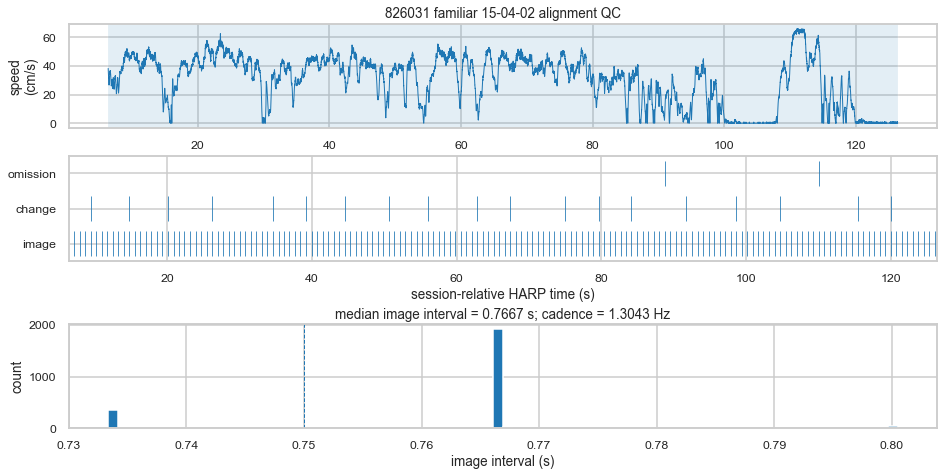

saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\826031_2026-01-30_15-04-02_population_trace_alignment.png


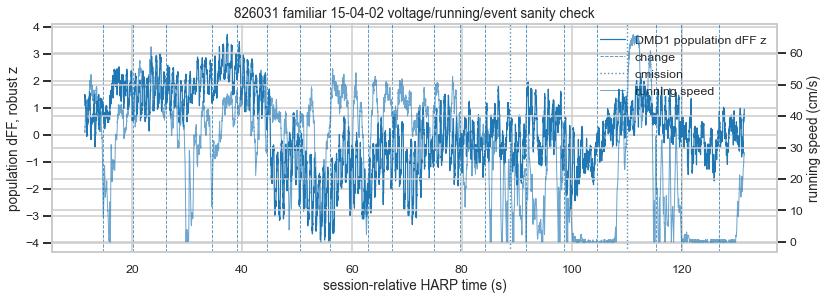

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\4058354708.py:78: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=r2_df[r2_df["model"].isin(["drift", "running", "stimulus", "full"])], x="model", y="r2", hue="dmd", ci=68, ax=axes[0])
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\4058354708.py:80: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=dropout_df[dropout_df["component"].isin(["running", "images", "change", "omission", "stimulus_all"])], x="component", y="delta_r2", hue="dmd", ci=68, ax=axes[1])


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\826031_2026-01-30_15-04-02_r2_dropout.png


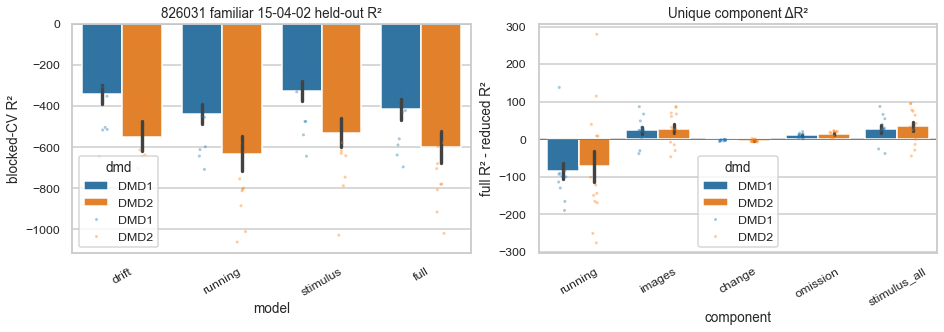

saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\826031_2026-01-30_15-04-02_corr_matrices.png


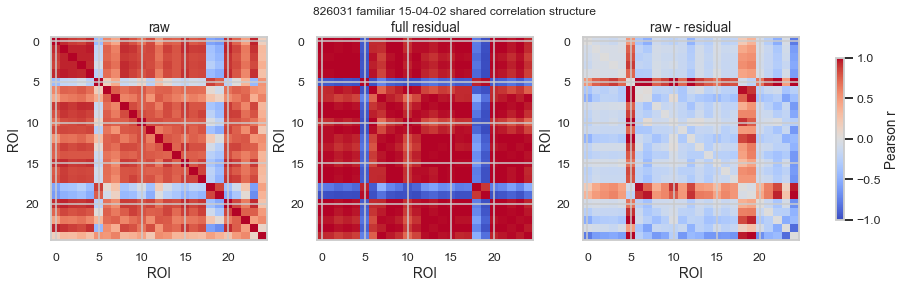

saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\826031_2026-01-30_15-04-02_psd_cadence_qc.png


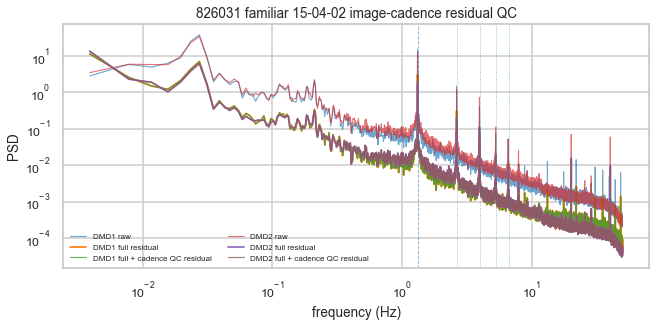

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\4058354708.py:144: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=long, x="metric", y="value", hue="pair_type", ci=68, ax=ax)


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\826031_2026-01-30_15-04-02_pairwise_shared_summary.png


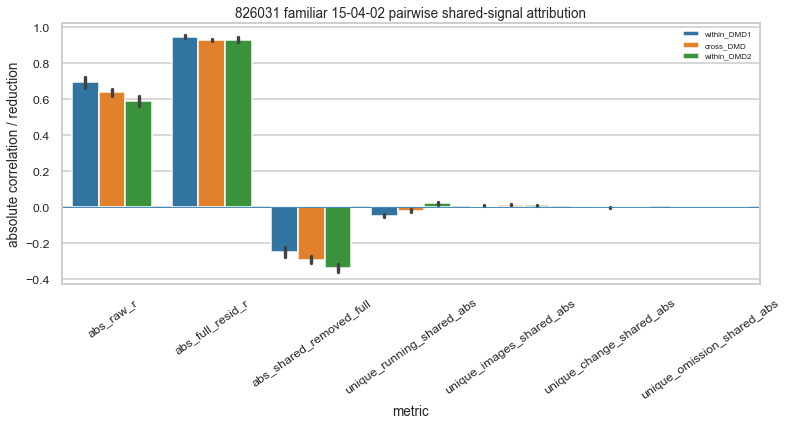

,dmd,model,count,mean,median,std
0,DMD1,drift,12,-340.237127,-287.331207,168.011471
1,DMD1,full,12,-412.601839,-386.641922,182.771314
2,DMD1,full_plus_cadence_qc,12,-412.618437,-386.700302,182.786375
3,DMD1,no_change,12,-409.540888,-383.449341,181.411674
4,DMD1,no_images,12,-436.237085,-427.363983,183.473011
5,DMD1,no_omission,12,-422.466397,-397.741486,187.756787
6,DMD1,no_running,12,-327.149906,-268.798401,169.889284
7,DMD1,no_stimulus,12,-439.821626,-430.525223,185.624099
8,DMD1,running,12,-439.821626,-430.525223,185.624099
9,DMD1,stimulus,12,-327.149906,-268.798401,169.889284


,dmd,component,count,mean,median,std
0,DMD1,cadence_qc_extra,12,-0.016598,-0.032852,0.045949
1,DMD1,change,12,-3.060951,-3.192581,1.940186
2,DMD1,images,12,23.635246,22.907501,35.306171
3,DMD1,omission,12,9.864558,9.852631,5.706206
4,DMD1,running,12,-85.451933,-95.947052,81.676519
5,DMD1,stimulus_all,12,27.219787,27.320801,34.796308
6,DMD2,cadence_qc_extra,13,-0.081224,-0.084656,0.058849
7,DMD2,change,13,-4.426128,-5.624817,3.108645
8,DMD2,images,13,28.146826,26.437622,44.159888
9,DMD2,omission,13,13.418914,16.285583,7.405774


,session_id,subject_id,session_date,session_type,session_type_norm,stimulus,key_session_label,is_key_session,dmd,trace,fs_hz,cadence_power,cadence_peak_over_background,raw_cadence_pob,cadence_pob_ratio_vs_raw
0,826031_2026-01-30_15-04-02,826031,2026-01-30,familiar,familiar,image_A,first_familiar,True,DMD1,raw,100.225851,1.042556,20.504647,20.504647,1.000000
1,826031_2026-01-30_15-04-02,826031,2026-01-30,familiar,familiar,image_A,first_familiar,True,DMD1,full_resid,100.225851,0.217648,22.657495,20.504647,1.104993
2,826031_2026-01-30_15-04-02,826031,2026-01-30,familiar,familiar,image_A,first_familiar,True,DMD1,full_plus_cadence_qc_resid,100.225851,0.217738,22.610920,20.504647,1.102722
3,826031_2026-01-30_15-04-02,826031,2026-01-30,familiar,familiar,image_A,first_familiar,True,DMD2,raw,100.225851,0.897814,12.578925,12.578925,1.000000
4,826031_2026-01-30_15-04-02,826031,2026-01-30,familiar,familiar,image_A,first_familiar,True,DMD2,full_resid,100.225851,0.138085,10.521160,12.578925,0.836412
5,826031_2026-01-30_15-04-02,826031,2026-01-30,familiar,familiar,image_A,first_familiar,True,DMD2,full_plus_cadence_qc_resid,100.225851,0.138215,10.535599,12.578925,0.837560


In [14]:
key_indices = list(session_df.index[session_df["is_key_session"]])
SESSION_INDEX = key_indices[0] if key_indices else 0
single_result = analyze_one_session(session_df.loc[SESSION_INDEX], registry, make_plots=True, save_outputs=True)

display(single_result["r2"].groupby(["dmd", "model"])["r2"].agg(["count", "mean", "median", "std"]).reset_index())
display(single_result["dropout"].groupby(["dmd", "component"])["delta_r2"].agg(["count", "mean", "median", "std"]).reset_index())
display(single_result["cadence"])

## Run all selected sessions

This loop processes sessions sequentially and writes per-session tables under each session's `analysis/derived/shared_voltage_attribution` directory, plus aggregate tables under `SAVE_ROOT/tables`. Failed sessions are recorded rather than stopping the whole batch.

In [15]:
all_results = []
failed_sessions = []

if RUN_ALL_SESSIONS:
    for idx, row in session_df.iterrows():
        # Avoid rerunning the session already computed above if it is in the selected set.
        try:
            if idx == SESSION_INDEX:
                res = single_result
            else:
                res = analyze_one_session(row, registry, make_plots=False, save_outputs=True)
            all_results.append(res)
        except Exception as exc:
            print("FAILED", row.get("session_id", idx), repr(exc))
            failed_sessions.append({"session_id": row.get("session_id", ""), "subject_id": row.get("subject_id", ""), "error": repr(exc)})
else:
    all_results = [single_result]

summary_df = pd.DataFrame([r["summary"] for r in all_results]) if all_results else pd.DataFrame()
r2_all = pd.concat([r["r2"] for r in all_results], ignore_index=True) if all_results else pd.DataFrame()
dropout_all = pd.concat([r["dropout"] for r in all_results], ignore_index=True) if all_results else pd.DataFrame()
pairwise_all = pd.concat([r["pairwise"] for r in all_results], ignore_index=True) if all_results else pd.DataFrame()
cadence_all = pd.concat([r["cadence"] for r in all_results], ignore_index=True) if all_results else pd.DataFrame()
failed_df = pd.DataFrame(failed_sessions)

summary_df.to_csv(TABLE_DIR / "session_summary.csv", index=False)
r2_all.to_csv(TABLE_DIR / "roi_model_r2_all.csv", index=False)
dropout_all.to_csv(TABLE_DIR / "roi_dropout_scores_all.csv", index=False)
pairwise_all.to_csv(TABLE_DIR / "pairwise_shared_signal_all.csv", index=False)
cadence_all.to_csv(TABLE_DIR / "cadence_qc_all.csv", index=False)
failed_df.to_csv(TABLE_DIR / "failed_sessions.csv", index=False)

print("Completed sessions:", len(summary_df))
print("Failed sessions:", len(failed_df))
display(summary_df)
if len(failed_df):
    display(failed_df)


=== 826031_2026-02-01_11-01-50 | mouse 826031 | familiar | other ===
trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
trace_source: derived_full_session
events: {'image': 2342, 'change': 284, 'omission': 14} source: voltage_qc


,dmd,n_rois,n_samples,fs_hz,time_start_sec,time_end_sec,time_mode_used
0,DMD1,15,178114,99.762434,14.734976,1800.106409,already_session_auto
1,DMD2,10,178114,99.762434,14.734976,1800.106409,already_session_auto


DMD1 design (178114, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}
DMD2 design (178114, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}

=== 826031_2026-02-02_10-23-53 | mouse 826031 | familiar | other ===
trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-02_10-23-53\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
trace_source: derived_full_session
events: {'image': 2350, 'change': 279, 'omission': 23} source: voltage_qc


,dmd,n_rois,n_samples,fs_hz,time_start_sec,time_end_sec,time_mode_used
0,DMD1,15,179778,100.35007,8.622528,1800.121029,already_session_auto
1,DMD2,11,179778,100.35007,8.622528,1800.121029,already_session_auto


DMD1 design (179778, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}
DMD2 design (179778, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}

=== 826031_2026-02-03_14-21-45 | mouse 826031 | familiar | other ===
trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-03_14-21-45\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
trace_source: derived_full_session
events: {'image': 2357, 'change': 268, 'omission': 20} source: voltage_qc


...

,dmd,n_rois,n_samples,fs_hz,time_start_sec,time_end_sec,time_mode_used
0,DMD1,16,174818,99.875873,3.228992,1800.134628,already_session_auto
1,DMD2,13,174818,99.875873,3.228992,1800.134628,already_session_auto


DMD1 design (174818, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}
DMD2 design (174818, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}

=== 826032_2026-02-11_14-46-30 | mouse 826032 | novel+ | first_novel_plus ===
trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-11_14-46-30\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
trace_source: derived_full_session
events: {'image': 2359, 'change': 283, 'omission': 21} source: voltage_qc


,dmd,n_rois,n_samples,fs_hz,time_start_sec,time_end_sec,time_mode_used
0,DMD1,13,179778,100.01906,2.704896,1800.132305,already_session_auto
1,DMD2,10,179778,100.01906,2.704896,1800.132305,already_session_auto


DMD1 design (179778, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}
DMD2 design (179778, 458) groups {'cadence_qc': 10, 'change': 50, 'drift': 12, 'image_flash': 40, 'image_identity': 280, 'intercept': 1, 'omission': 50, 'running': 15}
Completed sessions: 19
Failed sessions: 0


,session_id,subject_id,session_date,session_type,session_type_norm,stimulus,key_session_label,is_key_session,n_dmds,n_rois_total,n_image_events,n_change_events,n_omission_events,event_source,event_source_path,session_harp_t0_abs,trace_h5,trace_source,qc_dir,encoder_pkl
0,826031_2026-01-30_15-04-02,826031,2026-01-30,familiar,familiar,image_A,first_familiar,True,2,25,2352,285,15,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,1.926125e+05,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,826031_2026-02-01_11-01-50,826031,2026-02-01,familiar,familiar,image_A,other,False,2,25,2342,284,14,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,3.502452e+05,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,826031_2026-02-02_10-23-53,826031,2026-02-02,familiar,familiar,image_A,other,False,2,26,2350,279,23,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,4.353874e+05,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,826031_2026-02-03_14-21-45,826031,2026-02-03,familiar,familiar,image_A,other,False,2,29,2357,268,20,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,5.351472e+05,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,826031_2026-02-04_12-15-34,826031,2026-02-04,familiar,familiar,image_A,other,False,2,25,2359,285,31,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,6.150195e+05,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,826031_2026-02-05_09-28-56,826031,2026-02-05,familiar,familiar,image_A,other,False,2,21,2359,272,21,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,6.919566e+05,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,826031_2026-02-06_10-21-20,826031,2026-02-06,familiar,familiar,image_A,last_familiar,True,2,30,2360,283,26,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,7.805049e+05,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,826031_2026-02-10_10-48-51,826031,2026-02-10,novel,novel,image_B,first_novel,True,2,23,2356,288,19,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,1.127011e+06,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,826031_2026-02-11_12-42-21,826031,2026-02-11,novel+,novel+,image_B,first_novel_plus,True,2,19,2317,266,23,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,1.223432e+06,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,826031_2026-02-12_07-43-37,826031,2026-02-12,novel+,novel+,image_B,other,False,2,25,2065,254,14,voltage_qc,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,1.293170e+06,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,derived_full_session,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


## Aggregate plots: ROI-level source coding

Interpret these as held-out, ROI-wise linear predictability of dFF. The dropout score is the unique loss in full-model R² when the component is removed. Negative values can happen when predictors are weak or collinear; they should be treated as approximately zero unless they are consistent across sessions.

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\686741401.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  g = sns.catplot(


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\all_sessions_roi_dropout_by_session_type.png


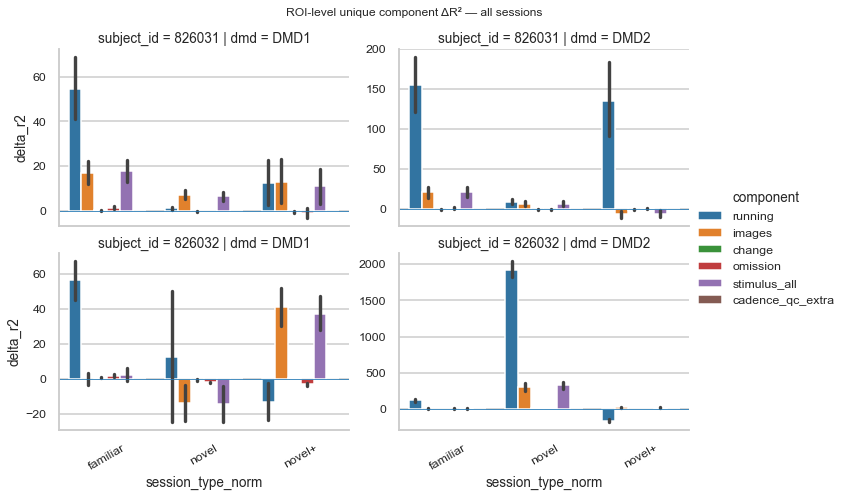

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\686741401.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  g = sns.catplot(


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\key_sessions_roi_dropout_by_key_label.png


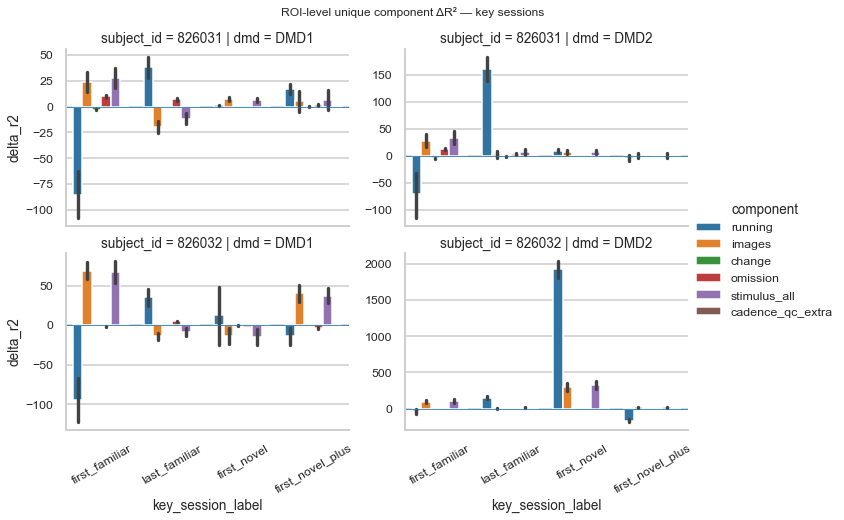

In [16]:
def plot_all_roi_dropout(dropout_all, key_only=False):
    df = dropout_all.copy()
    df = df[df["component"].isin(["running", "images", "change", "omission", "stimulus_all", "cadence_qc_extra"])]
    if key_only:
        df = df[df["is_key_session"]]
        x = "key_session_label"
        order = ["first_familiar", "last_familiar", "first_novel", "first_novel_plus"]
        order = [o for o in order if o in set(df[x])]
    else:
        x = "session_type_norm"
        order = ["familiar", "novel", "novel+"]
        order = [o for o in order if o in set(df[x])]
    g = None
    if HAS_SEABORN:
        g = sns.catplot(
            data=df,
            x=x,
            y="delta_r2",
            hue="component",
            col="dmd",
            row="subject_id",
            kind="bar",
            ci=68,
            order=order,
            height=3.2,
            aspect=1.55,
            sharey=False,
        )
        for ax in g.axes.flat:
            ax.axhline(0, lw=0.8)
            ax.tick_params(axis="x", rotation=30)
        g.fig.suptitle("ROI-level unique component ΔR²" + (" — key sessions" if key_only else " — all sessions"), y=1.03)
        return g.fig
    else:
        fig, ax = plt.subplots(figsize=(12, 5))
        df.groupby([x, "component"])["delta_r2"].mean().unstack().plot(kind="bar", ax=ax)
        ax.axhline(0, lw=0.8)
        return fig

fig = plot_all_roi_dropout(dropout_all, key_only=False)
savefig(fig, FIG_DIR / "all_sessions_roi_dropout_by_session_type.png")
plt.show()

fig = plot_all_roi_dropout(dropout_all, key_only=True)
savefig(fig, FIG_DIR / "key_sessions_roi_dropout_by_key_label.png")
plt.show()

## Aggregate plots: pairwise shared-signal attribution

The pairwise analysis is the most direct answer to the “shared dendritic voltage” question. `abs_shared_removed_full` is the reduction in absolute pairwise correlation after full residualization. `unique_*_shared_abs` is the additional absolute shared correlation that remains when that component is omitted from the model compared with the full residual. Positive values mean that component helped remove shared structure.

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\2221659627.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  g = sns.catplot(


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\all_sessions_pairwise_shared_attribution.png


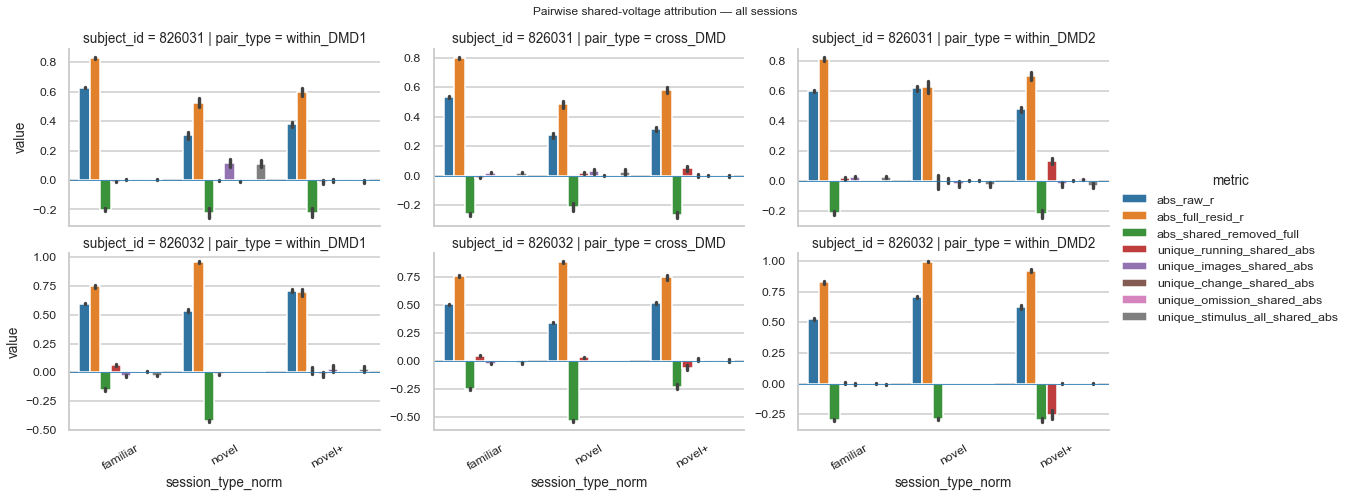

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\2221659627.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  g = sns.catplot(


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\key_sessions_pairwise_shared_attribution.png


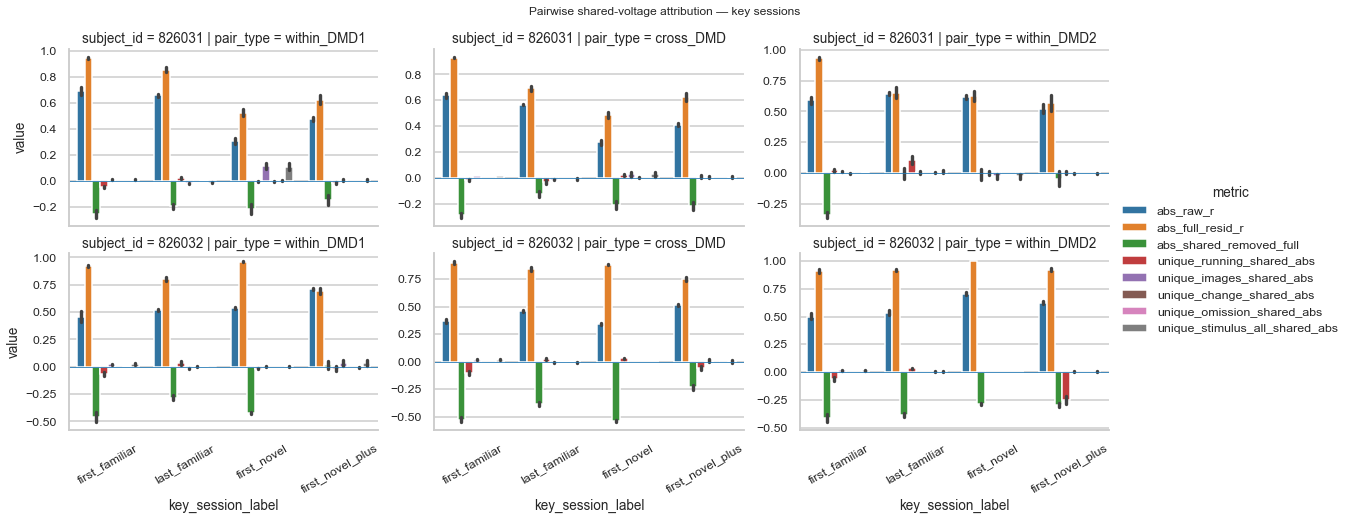

In [17]:
def pairwise_component_long(pairwise_all, key_only=False):
    df = pairwise_all.copy()
    if key_only:
        df = df[df["is_key_session"]].copy()
        x = "key_session_label"
    else:
        x = "session_type_norm"
    metric_cols = ["abs_raw_r", "abs_full_resid_r", "abs_shared_removed_full", "unique_running_shared_abs", "unique_images_shared_abs", "unique_change_shared_abs", "unique_omission_shared_abs", "unique_stimulus_all_shared_abs"]
    long = df.melt(id_vars=["subject_id", "session_id", x, "pair_type"], value_vars=metric_cols, var_name="metric", value_name="value")
    return long, x


def plot_pairwise_all(pairwise_all, key_only=False):
    long, x = pairwise_component_long(pairwise_all, key_only=key_only)
    if HAS_SEABORN:
        g = sns.catplot(
            data=long,
            x=x,
            y="value",
            hue="metric",
            col="pair_type",
            row="subject_id",
            kind="bar",
            ci=68,
            height=3.2,
            aspect=1.65,
            sharey=False,
        )
        for ax in g.axes.flat:
            ax.axhline(0, lw=0.8)
            ax.tick_params(axis="x", rotation=30)
        g.fig.suptitle("Pairwise shared-voltage attribution" + (" — key sessions" if key_only else " — all sessions"), y=1.03)
        return g.fig
    else:
        fig, ax = plt.subplots(figsize=(12, 5))
        long.groupby([x, "metric"])["value"].mean().unstack().plot(kind="bar", ax=ax)
        ax.axhline(0, lw=0.8)
        return fig

fig = plot_pairwise_all(pairwise_all, key_only=False)
savefig(fig, FIG_DIR / "all_sessions_pairwise_shared_attribution.png")
plt.show()

fig = plot_pairwise_all(pairwise_all, key_only=True)
savefig(fig, FIG_DIR / "key_sessions_pairwise_shared_attribution.png")
plt.show()

## Aggregate plots: residual image-cadence QC

A strong residual peak at 1.33 Hz after the full event model is a red flag. The image-event FIR model should remove deterministic flash-locked components if event timing, timebase alignment, and kernel flexibility are adequate. A residual 1.33 Hz peak can mean:

1. event times are shifted or jittered relative to voltage,
2. kernels are too short or too coarse,
3. image identity/change/omission terms are encoded incorrectly,
4. a non-visual periodic signal exists at the same cadence, such as expectation/ramping or hardware/processing artifact.

The `full_plus_cadence_qc` model is **diagnostic**, not a biological attribution model. If sine/cosine cadence regressors remove the peak but event kernels do not, the data contain cadence-locked structure that the event model is failing to capture.

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\1913562510.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  g = sns.catplot(


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\all_sessions_cadence_peak_qc.png


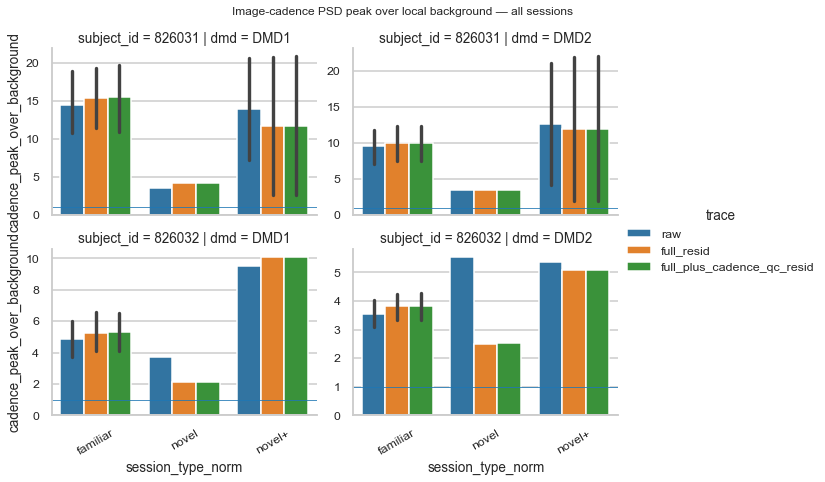

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_36344\1913562510.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  g = sns.catplot(


saved C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\key_sessions_cadence_peak_qc.png


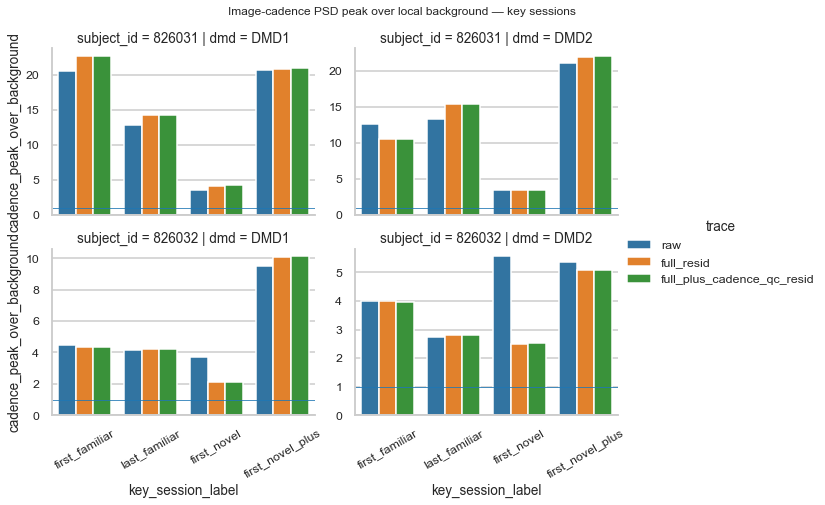

,subject_id,session_type_norm,dmd,trace,count,mean,median,std
0,826031,familiar,DMD1,full_plus_cadence_qc_resid,7,15.443493,14.305371,12.009636
1,826031,familiar,DMD1,full_resid,7,15.393734,14.281026,11.961825
2,826031,familiar,DMD1,raw,7,14.505468,12.763694,11.485996
3,826031,familiar,DMD2,full_plus_cadence_qc_resid,7,9.927808,10.535599,6.793032
4,826031,familiar,DMD2,full_resid,7,9.913249,10.521160,6.807969
5,826031,familiar,DMD2,raw,7,9.615371,12.578925,6.396396
6,826031,novel,DMD1,full_plus_cadence_qc_resid,1,4.191594,4.191594,NaN
7,826031,novel,DMD1,full_resid,1,4.165513,4.165513,NaN
8,826031,novel,DMD1,raw,1,3.501005,3.501005,NaN
9,826031,novel,DMD2,full_plus_cadence_qc_resid,1,3.508666,3.508666,NaN


In [18]:
def plot_cadence_all(cadence_all, key_only=False):
    df = cadence_all.copy()
    df = df[df["trace"].isin(["raw", "full_resid", "full_plus_cadence_qc_resid"])]
    if key_only:
        df = df[df["is_key_session"]]
        x = "key_session_label"
    else:
        x = "session_type_norm"
    if HAS_SEABORN:
        g = sns.catplot(
            data=df,
            x=x,
            y="cadence_peak_over_background",
            hue="trace",
            col="dmd",
            row="subject_id",
            kind="bar",
            ci=68,
            height=3.1,
            aspect=1.45,
            sharey=False,
        )
        for ax in g.axes.flat:
            ax.axhline(1.0, lw=0.8)
            ax.tick_params(axis="x", rotation=30)
        g.fig.suptitle("Image-cadence PSD peak over local background" + (" — key sessions" if key_only else " — all sessions"), y=1.03)
        return g.fig
    else:
        fig, ax = plt.subplots(figsize=(10, 5))
        df.groupby([x, "trace"])["cadence_peak_over_background"].mean().unstack().plot(kind="bar", ax=ax)
        ax.axhline(1.0, lw=0.8)
        return fig

fig = plot_cadence_all(cadence_all, key_only=False)
savefig(fig, FIG_DIR / "all_sessions_cadence_peak_qc.png")
plt.show()

fig = plot_cadence_all(cadence_all, key_only=True)
savefig(fig, FIG_DIR / "key_sessions_cadence_peak_qc.png")
plt.show()

display(cadence_all.groupby(["subject_id", "session_type_norm", "dmd", "trace"])["cadence_peak_over_background"].agg(["count", "mean", "median", "std"]).reset_index())

## Compact statistical summaries

These are intentionally descriptive because there are only two voltage mice and ROIs are not tracked across sessions. Treat mouse/session as the meaningful repeated-measures units; ROI-level points are useful for visualization but not independent biological replicates.

In [19]:
# Session-level ROI dropout summaries.
roi_session_summary = (
    dropout_all
    .groupby(["subject_id", "session_id", "session_type_norm", "key_session_label", "is_key_session", "dmd", "component"], as_index=False)
    .agg(delta_r2_mean=("delta_r2", "mean"), delta_r2_median=("delta_r2", "median"), n_roi=("delta_r2", "size"))
)
roi_session_summary.to_csv(TABLE_DIR / "session_level_roi_dropout_summary.csv", index=False)
display(roi_session_summary.head(30))

# Session-level pairwise summaries.
pair_session_summary = (
    pairwise_all
    .groupby(["subject_id", "session_id", "session_type_norm", "key_session_label", "is_key_session", "pair_type"], as_index=False)
    .agg(
        abs_raw_r_mean=("abs_raw_r", "mean"),
        abs_full_resid_r_mean=("abs_full_resid_r", "mean"),
        abs_shared_removed_full_mean=("abs_shared_removed_full", "mean"),
        unique_running_shared_abs_mean=("unique_running_shared_abs", "mean"),
        unique_images_shared_abs_mean=("unique_images_shared_abs", "mean"),
        unique_change_shared_abs_mean=("unique_change_shared_abs", "mean"),
        unique_omission_shared_abs_mean=("unique_omission_shared_abs", "mean"),
        n_pairs=("raw_r", "size"),
    )
)
pair_session_summary.to_csv(TABLE_DIR / "session_level_pairwise_shared_summary.csv", index=False)
display(pair_session_summary.head(30))

# Key-session table: useful for lab-meeting slides.
key_roi = roi_session_summary[roi_session_summary["is_key_session"]].copy()
key_pair = pair_session_summary[pair_session_summary["is_key_session"]].copy()
key_roi.to_csv(TABLE_DIR / "key_sessions_roi_dropout_summary.csv", index=False)
key_pair.to_csv(TABLE_DIR / "key_sessions_pairwise_shared_summary.csv", index=False)

display(key_roi)
display(key_pair)

,subject_id,session_id,session_type_norm,key_session_label,is_key_session,dmd,component,delta_r2_mean,delta_r2_median,n_roi
0,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,cadence_qc_extra,-0.016598,-0.032852,12
1,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,change,-3.060951,-3.192581,12
2,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,images,23.635246,22.907501,12
3,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,omission,9.864558,9.852631,12
4,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,running,-85.451933,-95.947052,12
5,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,stimulus_all,27.219787,27.320801,12
6,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD2,cadence_qc_extra,-0.081224,-0.084656,13
7,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD2,change,-4.426128,-5.624817,13
8,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD2,images,28.146826,26.437622,13
9,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD2,omission,13.418914,16.285583,13


,subject_id,session_id,session_type_norm,key_session_label,is_key_session,pair_type,abs_raw_r_mean,abs_full_resid_r_mean,abs_shared_removed_full_mean,unique_running_shared_abs_mean,unique_images_shared_abs_mean,unique_change_shared_abs_mean,unique_omission_shared_abs_mean,n_pairs
0,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,cross_DMD,0.638650,0.930900,-0.292250,-0.019608,0.013900,-0.002833,0.001405,156
1,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,within_DMD1,0.695104,0.948155,-0.253051,-0.047284,0.007700,-0.001172,0.000913,66
2,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,within_DMD2,0.591127,0.931922,-0.340796,0.020517,0.010543,-0.004344,0.002033,78
3,826031,826031_2026-02-01_11-01-50,familiar,other,False,cross_DMD,0.393769,0.853561,-0.459792,0.092349,-0.001754,0.000918,-0.000775,150
4,826031,826031_2026-02-01_11-01-50,familiar,other,False,within_DMD1,0.509894,0.813675,-0.303781,0.113601,0.002273,0.001186,-0.001797,105
5,826031,826031_2026-02-01_11-01-50,familiar,other,False,within_DMD2,0.563806,0.884868,-0.321062,0.075153,-0.006180,0.000294,-0.000449,45
6,826031,826031_2026-02-02_10-23-53,familiar,other,False,cross_DMD,0.618156,0.684798,-0.066642,0.002519,0.114733,-0.000828,-0.002797,165
7,826031,826031_2026-02-02_10-23-53,familiar,other,False,within_DMD1,0.756874,0.647511,0.109363,0.033501,0.158649,-0.001015,-0.009909,105
8,826031,826031_2026-02-02_10-23-53,familiar,other,False,within_DMD2,0.634598,0.758627,-0.124028,-0.002655,0.060317,-0.000768,0.000381,55
9,826031,826031_2026-02-03_14-21-45,familiar,other,False,cross_DMD,0.493503,0.757782,-0.264279,-0.129403,0.062218,-0.002720,-0.007365,190


,subject_id,session_id,session_type_norm,key_session_label,is_key_session,dmd,component,delta_r2_mean,delta_r2_median,n_roi
0,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,cadence_qc_extra,-0.016598,-0.032852,12
1,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,change,-3.060951,-3.192581,12
2,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,images,23.635246,22.907501,12
3,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,omission,9.864558,9.852631,12
4,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,DMD1,running,-85.451933,-95.947052,12
...,...,...,...,...,...,...,...,...,...,...
223,826032,826032_2026-02-11_14-46-30,novel+,first_novel_plus,True,DMD2,change,0.087408,0.095608,10
224,826032,826032_2026-02-11_14-46-30,novel+,first_novel_plus,True,DMD2,images,17.943903,25.586586,10
225,826032,826032_2026-02-11_14-46-30,novel+,first_novel_plus,True,DMD2,omission,-1.986786,-3.423653,10
226,826032,826032_2026-02-11_14-46-30,novel+,first_novel_plus,True,DMD2,running,-166.607533,-159.103313,10


,subject_id,session_id,session_type_norm,key_session_label,is_key_session,pair_type,abs_raw_r_mean,abs_full_resid_r_mean,abs_shared_removed_full_mean,unique_running_shared_abs_mean,unique_images_shared_abs_mean,unique_change_shared_abs_mean,unique_omission_shared_abs_mean,n_pairs
0,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,cross_DMD,0.638650,0.930900,-0.292250,-0.019608,0.013900,-0.002833,1.404995e-03,156
1,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,within_DMD1,0.695104,0.948155,-0.253051,-0.047284,0.007700,-0.001172,9.134574e-04,66
2,826031,826031_2026-01-30_15-04-02,familiar,first_familiar,True,within_DMD2,0.591127,0.931922,-0.340796,0.020517,0.010543,-0.004344,2.032853e-03,78
18,826031,826031_2026-02-06_10-21-20,familiar,last_familiar,True,cross_DMD,0.566929,0.692586,-0.125657,-0.033598,-0.014173,0.001135,6.955072e-04,209
19,826031,826031_2026-02-06_10-21-20,familiar,last_familiar,True,within_DMD1,0.657129,0.855910,-0.198781,0.020262,-0.018637,-0.000361,2.671387e-03,171
20,826031,826031_2026-02-06_10-21-20,familiar,last_familiar,True,within_DMD2,0.645291,0.653064,-0.007774,0.103566,0.004971,0.000240,3.808691e-03,55
21,826031,826031_2026-02-10_10-48-51,novel,first_novel,True,cross_DMD,0.275042,0.486811,-0.211769,0.018608,0.027869,-0.000119,-2.587193e-03,130
22,826031,826031_2026-02-10_10-48-51,novel,first_novel,True,within_DMD1,0.303975,0.525376,-0.221401,-0.004371,0.115011,-0.008284,9.472949e-04,78
23,826031,826031_2026-02-10_10-48-51,novel,first_novel,True,within_DMD2,0.615671,0.625403,-0.009731,0.001793,-0.025209,-0.000334,1.595592e-03,45
24,826031,826031_2026-02-11_12-42-21,novel+,first_novel_plus,True,cross_DMD,0.409088,0.628046,-0.218957,0.009284,0.005869,-0.000662,-1.280056e-03,84


## Interpretation checklist

Use these checks before turning the figures into lab-meeting claims:

1. **Alignment first:** event times should sit inside the imaging epoch, and voltage time should start near the detected imaging start rather than Bonsai start.
2. **Cadence peak:** if full residual PSD still has a large 1.33 Hz peak, inspect whether `full_plus_cadence_qc` removes it. If yes, the event model is underfitting cadence-locked structure; if no, suspect a non-event artifact or broader periodic physiology.
3. **Running:** running should be interpreted beyond drift. If running ΔR² is tiny but pairwise `unique_running_shared_abs` is positive, running may explain common-mode covariance without explaining much ROI-specific variance.
4. **Image presentations vs changes/omissions:** changes and omissions are rare and partially collinear with image timing. Strong inference should rely on consistency across sessions/mice, not individual ROI pips.
5. **DMD differences:** prioritize session-level within-DMD and cross-DMD summaries. ROI identities are not longitudinal, so do not interpret a ROI across days as the same dendrite.
6. **Novelty:** compare first familiar, last familiar, first novel, and first novel+ within each mouse first, then pool descriptively across the two mice.